# Part 1: Train the expert

Before I can evaluate and compare the two different approaches to modeling an agent's memory for imitation in partially observable environments (POMDPs), I first need to train an expert agent capable of solving the task using an optimal policy (thus assuming that the expert's policy is optimal). I can then generate a set of trajectories from this expert, which will be used to train the models to imitate its behavior.

## Libraries, environment and support functions

This section can be skipped, as it only contains the imported libraries, the environment class, and all the supporting functions required for the code to perform the analysis correctly (e.g., setting the random seed, generating plots, and handling other auxiliary tasks).

In [36]:
# Basic libraries
import random
import numpy as np
import torch
import pickle
import os
import shutil
import glob
import time

# Environment and RL libraries
import gymnasium as gym
from gymnasium import spaces

# Recurrent PPO and Stable Baselines3 utilities
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement
from stable_baselines3.common.monitor import Monitor 
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Plots 
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import networkx as nx
from matplotlib.lines import Line2D
import io
import imageio.v2 as imageio

# Neural Network libraries
import torch
import torch.nn as nn
import torch.nn.functional as F


In [37]:
def set_seed(seed: int = 42):
    # 1. Standard Python
    random.seed(seed)
    
    # 2. Numpy
    np.random.seed(seed)
    
    # 3. PyTorch
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True)
    
    # GPU configurations (if available)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Set the global seed for reproducibility
SEED = 42
set_seed(SEED)

# GPU device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [38]:
# Define the matrix representing the gridworld, where 1s are walls and 0s are free spaces
# If you look more closely, this 9x9 grid is specifically designed to be cutted at any size (2x2, 3x3, ..., 9x9)
# while still maintaining a valid path from the top-left corner (start) to the bottom-right corner (goal).
# NOTE: All the values on the principal diagonal are 0, thus ensuring that the goal does not overlap with a wall. 

GRID_WORD = np.array([
    [0, 1, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 0, 1, 1, 0, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 1, 0, 1, 1, 1, 0, 1],
    [0, 0, 1, 0, 0, 0, 1, 0, 0],
    [1, 0, 0, 0, 1, 0, 0, 1, 0],
    [0, 0, 1, 1, 1, 1, 0, 0, 0],
    [0, 1, 0, 0, 0, 1, 1, 0, 1],
    [0, 0, 0, 1, 0, 0, 0, 0, 0]
])

class POMDPGridworld(gym.Env):
    '''
    A partially observable gridworld environment where the agent receives binary observations about adjacent walls 
    instead of its exact coordinates. The agent must navigate from the top-left corner to the bottom-right corner 
    while avoiding walls. The environment is designed to be scalable, allowing for different grid sizes 
    (from 2x2 to 9x9) while maintaining a valid path to the goal.

    Input:
    - size: The size of the grid (size x size). Must be between 2 and 9.
    - max_steps: The maximum number of steps before the episode is truncated.

    Functions:
    - reset(): Resets the environment to the initial state and returns the initial observation.
    - step(action): Takes an action and returns the new observation, reward, termination status, and truncation status.
    - visualize_grid(): Prints a visual representation of the grid, showing the agent's position, the goal, and 
                        the walls.
    '''
    def __init__(self, size=5, max_steps=500):
        super(POMDPGridworld, self).__init__()

        try:
            size = int(size)
            if size < 2 or size > 9:
                raise ValueError(f"Invalid size: {size}. Size must be between 2 and 9.")
        except ValueError as e:
            print(f"Invalid size: {size}. {e}")
            raise

        self.size = size
        self.max_steps = max_steps
        self.current_step = 0
        
        # ACTION: 0=UP, 1=RIGHT, 2=DOWN, 3=LEFT
        self.action_space = spaces.Discrete(4)
        
        # POMDP OBSERVATION: 4 binary sensors for adjacent walls (0=free, 1=wall)
        # Instead of returning coordinates (x,y), return what's around the agent:
        # [wall_up, wall_right, wall_down, wall_left]
        self.observation_space = spaces.MultiBinary(4)
        
        # INTERNAL STATE (hidden from the agent)
        self.agent_pos = np.zeros(2, dtype=int)  # Agent's position (x,y)
        self.goal_pos = np.array([size-1, size-1], dtype=int)  # Goal position
        self.grid = GRID_WORD[:self.size, :self.size]  # Walls based on the GRID_WORD matrix

    def reset(self, **kwargs):
        super().reset(**kwargs)
        # Reset the agent to the starting position (0,0) and reset the step counter
        self.agent_pos = np.zeros(2, dtype=int)
        self.current_step = 0
        
        # Return the OBSERVATION (not the internal state)
        obs = self._get_observation()
        return obs, {}

    def step(self, action):
        self.current_step += 1
        
        # 1. Update the TRUE state (the coordinates (x,y))
        self._move_agent(action)
        
        # 2. Check if the goal has been reached and decide the reward
        terminated = np.array_equal(self.agent_pos, self.goal_pos)
        reward = 1.0 if terminated else -0.01 # Small time penalty
        
        truncated = self.current_step >= self.max_steps
        
        # 3. Calculate the PARTIAL observation
        obs = self._get_observation()
        
        # Return the observation
        return obs, reward, terminated, truncated, {}

    def _get_observation(self):

        # Initialize the observation with zeros (no walls)
        obs = np.zeros(4, dtype=np.int8)

        # Check for walls in the four adjacent directions and update the observation accordingly
        if self.agent_pos[1] == 0 or self.grid[self.agent_pos[1]-1, self.agent_pos[0]] == 1:
            obs[0] = 1
        if self.agent_pos[0] == 0 or self.grid[self.agent_pos[1], self.agent_pos[0]-1] == 1:
            obs[3] = 1
        if self.agent_pos[1] == self.size-1 or self.grid[self.agent_pos[1]+1, self.agent_pos[0]] == 1:
            obs[2] = 1
        if self.agent_pos[0] == self.size-1 or self.grid[self.agent_pos[1], self.agent_pos[0]+1] == 1:
            obs[1] = 1
        
        # Return the observation
        return obs
    
    def _move_agent(self, action):

        # Be sure to check for a valid action
        try:
            action = int(action)
            if action == 0 and self.agent_pos[1] > 0:  # Up
                if self.grid[self.agent_pos[1]-1, self.agent_pos[0]] == 0:
                    self.agent_pos[1] -= 1
            elif action == 1 and self.agent_pos[0] < self.size - 1:  # Right
                if self.grid[self.agent_pos[1], self.agent_pos[0]+1] == 0:
                    self.agent_pos[0] += 1
            elif action == 2 and self.agent_pos[1] < self.size - 1:  # Down
                if self.grid[self.agent_pos[1]+1, self.agent_pos[0]] == 0:
                    self.agent_pos[1] += 1
            elif action == 3 and self.agent_pos[0] > 0:  # Left
                if self.grid[self.agent_pos[1], self.agent_pos[0]-1] == 0:
                    self.agent_pos[0] -= 1
        except ValueError:
            print(f"Invalid action: {action}. Action must be an integer between 0 and {self.action_space.n - 1}.") # type: ignore

    def visualize_grid(self):
        grid = np.full((self.size, self.size), '-')
        grid[self.goal_pos[1], self.goal_pos[0]] = 'G'  # Goal
        for y in range(self.size):
            for x in range(self.size):
                if self.grid[y, x] == 1:
                    grid[y, x] = 'W'  # Wall
        grid[self.agent_pos[1], self.agent_pos[0]] = 'A'  # Agent
        print("\n".join("".join(row) for row in grid))

grid = POMDPGridworld(size=2)
obs, _ = grid.reset()
print("Initial observation:", obs)
grid.visualize_grid()
obs, reward, terminated, _, _ = grid.step(2)  # Try to move down
print("Observation after action 1 (down):", obs)
print("Reward:", reward, "Terminated:", terminated)
grid.visualize_grid()
obs, reward, terminated, _, _ = grid.step(1)  # Try to move right
print("Observation after action 2 (right):", obs)
print("Reward:", reward, "Terminated:", terminated)
grid.visualize_grid()

Initial observation: [1 1 0 1]
AW
-G
Observation after action 1 (down): [0 0 1 1]
Reward: -0.01 Terminated: False
-W
AG
Observation after action 2 (right): [1 1 1 0]
Reward: 1.0 Terminated: True
-W
-A


In [44]:
def plot_tensorboard_logs(log_dirs, size, labels=None):

    if labels is None:
        labels = [os.path.basename(d) for d in log_dirs]

    metrics = [
        ('eval/mean_reward', 'Eval: Mean Reward'),
        ('rollout/ep_rew_mean', 'Rollout: Mean Reward'),
        ('eval/mean_ep_length', 'Eval: Mean Episode Length'),
        ('rollout/ep_len_mean', 'Rollout: Mean Episode Length'),
        ('train/approx_kl', 'Train: Approx KL (Stability)'),
        ('train/entropy_loss', 'Train: Entropy Loss (Exploration)'),
        ('train/value_loss', 'Train: Value Loss (Reward Estimation Error)'),
    ]

    targets = {
    3: {
        'eval/mean_reward': 0.97,
        'rollout/ep_rew_mean': 0.97,
        'eval/mean_ep_length': 4,
        'rollout/ep_len_mean': 4,
    },
    6: {
        'eval/mean_reward': 0.91,
        'rollout/ep_rew_mean': 0.91,
        'eval/mean_ep_length': 10,
        'rollout/ep_len_mean': 10,
    },
    9: {
        'eval/mean_reward': 0.85,
        'rollout/ep_rew_mean': 0.85,
        'eval/mean_ep_length': 16,
        'rollout/ep_len_mean': 16,
    }
    }

    colors = plt.cm.tab10.colors

    fig, axs = plt.subplots(4, 2, figsize=(16, 20))
    axs = axs.flatten()

    # Carica tutti gli EventAccumulator
    accumulators = []

    for log_dir in log_dirs:
        event_files = glob.glob(os.path.join(log_dir, 'events.out.tfevents.*'))

        if not event_files:
            print(f"No event file found in {log_dir}")
            accumulators.append(None)
            continue

        ea = EventAccumulator(event_files[0])
        ea.Reload()
        accumulators.append(ea)

    for idx, (tag, title) in enumerate(metrics):

        ax = axs[idx]

        if size in targets and tag in targets[size]:
            ax.axhline(
                y=targets[size][tag],
                color='red',
                linestyle='--',
                linewidth=2,
                alpha=0.8
            )

        found = False

        for run_idx, ea in enumerate(accumulators):

            if ea is None:
                continue

            if tag not in ea.Tags()['scalars']:
                continue

            events = ea.Scalars(tag)
            steps = [e.step for e in events]
            values = [e.value for e in events]

            color = colors[run_idx % len(colors)]

            # curva smussata (EMA)
            weight = 0.7
            smoothed = []
            last = values[0]

            for v in values:
                last = last * weight + (1 - weight) * v
                smoothed.append(last)

            # dati grezzi
            ax.plot(
                steps,
                values,
                color=color,
                alpha=0.25,
                linewidth=1
            )

            # trend
            ax.plot(
                steps,
                smoothed,
                color=color,
                linewidth=2.5,
                label=labels[run_idx]
            )

            found = True

        if found:
            ax.set_title(title, fontsize=14, fontweight='bold')
            ax.set_xlabel("Timesteps")
            ax.set_ylabel("Value")
            ax.grid(True, linestyle='--', alpha=0.6)
            ax.legend()
        else:
            ax.text(
                0.5,
                0.5,
                f"Data not found:\n{tag}",
                ha='center',
                va='center',
                color='red'
            )
            ax.set_title(title)

    fig.delaxes(axs[7])

    plt.tight_layout()
    
    if not os.path.exists(f'./plots/RecurrentPPO/'):
        os.makedirs('./plots/RecurrentPPO', exist_ok=True)
    if os.path.exists(f'./plots/RecurrentPPO/RecurrentPPO_{size}.png'):
        os.remove(f'./plots/RecurrentPPO/RecurrentPPO_{size}.png')
    plt.savefig(f'./plots/RecurrentPPO/RecurrentPPO_{size}.png')
    plt.show()
    plt.close()

In [43]:
def plot_fsc_training_history(size, Ms, losses):

    best_r = int(np.argmin(losses))
    plt.figure(figsize=(10, 4))

    plt.plot(Ms, losses, marker='o', linewidth=2, color='#1f77b4', label='Best NLL')
    plt.scatter([Ms[best_r]], [losses[best_r]], color='red', zorder=5, s=100, label=f'Best: M={Ms[best_r]}')

    plt.xlabel("Number of internal states M")
    plt.ylabel("Average NLL")
    plt.title(f"FSC {size}x{size} - Best final loss for each M parameter")
    plt.xticks(Ms)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    if not os.path.exists(f'./plots/FSC/'):
        os.makedirs('./plots/FSC', exist_ok=True)
    if os.path.exists(f'./plots/FSC/FSC_curve_{size}x{size}.png'):
        os.remove(f'./plots/FSC/FSC_curve_{size}x{size}.png')
    plt.savefig(f'./plots/FSC/FSC_curve_{size}x{size}.png')
    plt.show()
    plt.close()

def plot_fsc_graph(fsc, size, action_names=None, threshold=0.05, figsize=(16, 7)):
    """
    Visualize the trained FSC as a directed graph + policy heatmap.
    Left panel - transition graph:
    - Nodes : internal states m_0..m_{M-1}
            size ∝ rho(m)  (initial distribution)
            color     = dominant action argmax_a π(a|m)
    - Edges : g(m'|m) marginalized uniformly over A and Y
            width ∝ transition probability
            only edges with p > threshold

    Right panel - heatmap π(a|m):
    shows the probability distribution of each action for each state.

    Input:
    - fsc: The trained FSC model to visualize
    - size: Size of the gridworld (used for naming the saved model)
    - action_names: Optional list of action names for labeling the heatmap (default: ['Up', 'Right', 'Down', 'Left'])
    - threshold: Minimum transition probability to display an edge in the graph
    - figsize: Size of the overall figure (width, height)
    - title: Title for the graph panel
    """
    if action_names is None:
        action_names = ['Up', 'Right', 'Down', 'Left']

    action_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

    fsc.eval()
    with torch.no_grad():
        rho = F.softmax(fsc.theta_pi,  dim=0).numpy()   
        pie = F.softmax(fsc.theta_pie, dim=0).numpy()   
        g   = F.softmax(fsc.theta_g,   dim=0).numpy()   

    M = fsc.M
    dominant_action = np.argmax(pie, axis=0)   
    g_marginal = g.mean(axis=(2, 3))

    fig, axes = plt.subplots(1, 2, figsize=figsize,
                            gridspec_kw={'width_ratios': [2.5, 1]})

    # ── Left panel: transition graph ─────────────────────────────
    ax_graph = axes[0]

    G = nx.DiGraph()
    G.add_nodes_from(range(M))
    for m_prev in range(M):
        for m_next in range(M):
            w = float(g_marginal[m_next, m_prev])
            if w > threshold:
                G.add_edge(m_prev, m_next, weight=w)

    pos         = nx.spring_layout(G, seed=42, k=2.5)
    node_sizes  = [5000 * rho[m] + 500 for m in range(M)]
    node_colors = [action_colors[dominant_action[m]] for m in range(M)]
    edge_data   = list(G.edges(data=True))
    edge_widths = [d['weight'] * 14 for _, _, d in edge_data]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors,
                        alpha=0.92, ax=ax_graph)
    nx.draw_networkx_labels(G, pos,
                            labels={m: f"m{m}" for m in range(M)},
                            font_color='white', font_weight='bold',
                            font_size=10, ax=ax_graph)
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.55,
                        edge_color='#444444', arrows=True, arrowsize=20,
                        connectionstyle='arc3,rad=0.15', ax=ax_graph)

    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edge_data}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                font_size=7, alpha=0.8, ax=ax_graph)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
                markerfacecolor=action_colors[a], markersize=13,
                label=f"{action_names[a]}") for a in range(fsc.A)
    ]
    ax_graph.legend(handles=legend_elements, loc='upper left',
                    fontsize=9, title='Dominant action π(a|m)')
    ax_graph.set_title(
        f"FSC {size}x{size} - Graph of Internal States for M={M}\n"
        r"(edges = $\bar{g}(m'|m)$ over A,Y  ·  node ∝ $\rho(m_0)$  ·  color = dominant action)",
        fontsize=11, fontweight='bold'
    )
    ax_graph.axis('off')
 
    # ── Right panel: heatmap π(a|m) ───────────────────────────────────────
    ax_heat = axes[1]
    im = ax_heat.imshow(pie, cmap='Blues', aspect='auto', vmin=0, vmax=1)

    ax_heat.set_xticks(range(M))
    ax_heat.set_xticklabels([f"m{m}" for m in range(M)], fontsize=8)
    ax_heat.set_yticks(range(fsc.A))
    ax_heat.set_yticklabels(action_names, fontsize=9)
    ax_heat.set_xlabel("Internal state m", fontsize=9)
    ax_heat.set_title("π(a | m)", fontsize=12, fontweight='bold')

    for a in range(fsc.A):
        for m in range(M):
            ax_heat.text(m, a, f"{pie[a, m]:.2f}",
                        ha='center', va='center', fontsize=7,
                        color='white' if pie[a, m] > 0.5 else 'black')

    plt.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04, label='Probability')
    plt.tight_layout()
    
    if not os.path.exists(f'./plots/FSC/'):
        os.makedirs('./plots/FSC', exist_ok=True)
    if os.path.exists(f'./plots/FSC/FSC_graph_{size}x{size}_M{M}.png'):
        os.remove(f'./plots/FSC/FSC_graph_{size}x{size}_M{M}.png')
    plt.savefig(f'./plots/FSC/FSC_graph_{size}x{size}_M{M}.png')
    plt.show()
    plt.close()

In [ ]:
def plot_lstm_training_history(size, history_train, history_val):
    
    plt.figure(figsize=(10, 5))

    plt.plot(history_train, label='Train Loss', alpha=0.6, linewidth=2)
    plt.plot(history_val, label='Val Loss', alpha=0.6, linewidth=2, linestyle='--')

    plt.xlabel("Epochs")
    plt.ylabel("Cross-Entropy Loss")
    plt.title(f"LSTM {size}x{size} - Training and Validation Loss Curves")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    if not os.path.exists(f'./plots/LSTM/'):
        os.makedirs('./plots/LSTM', exist_ok=True)
    if os.path.exists(f'./plots/LSTM/LSTM_curve_{size}x{size}.png'):
        os.remove(f'./plots/LSTM/LSTM_curve_{size}x{size}.png')
    plt.savefig(f'./plots/LSTM/LSTM_curve_{size}x{size}.png')
    plt.show()
    plt.close()

## Recurrent PPO

Recurrent PPO is a variant of the Proximal Policy Optimization algorithm that integrates Recurrent Neural Networks (RNNs), such as LSTMs or GRUs, to handle Partially Observable Markov Decision Processes (POMDPs).  By maintaining hidden states, the agent can leverage action-observation history to infer full states from partial observations, effectively solving tasks where the current observation does not represent the complete system state. 


The main difference is while standard PPO treats each observation as independent, Recurrent PPO maintains a hidden state that acts as memory, allowing the agent to track action-observation history and infer latent state dynamics. Is more slow and less competitive in many environments, but can outperforme the standard version in scenarios with masked observations where history is critical. 

In [41]:
def train_rppo(size, max_steps, total_timesteps=50000, verbose_level=1, lr=3e-4, SEED=42):
    '''
    Trains a RecurrentPPO agent on the POMDPGridworld environment with early stopping based on 
    evaluation performance.

    Inputs:
    - size: Size of the gridworld
    - max_steps: Maximum steps per episode
    - total_timesteps: Total timesteps for training
    - verbose_level: 0 (no logs), 1 (callback logs), 2 (full logs)
    - lr: Learning rate for the PPO agent
    - SEED: Random seed for reproducibility

    Output:
    - model: The trained RecurrentPPO model
    '''

    # 0: Set verbose levels
    if verbose_level == 0:
        verbose_learn = 0
        verbose_callback = 0
    elif verbose_level == 1:
        verbose_learn = 0
        verbose_callback = 1
    elif verbose_level == 2:
        verbose_learn = 1
        verbose_callback = 1
    else:
        raise ValueError(f"Invalid verbose level: {verbose_level}. Choose 0 (no logs), 1 (callback logs), or 2 (full logs).")

    # 1. Initialize the environment and wrap it with Monitor
    env = Monitor(POMDPGridworld(size=size, max_steps=max_steps))
    eval_env = Monitor(POMDPGridworld(size=size, max_steps=max_steps))

    # 2. Automatic check to ensure the environment adheres to standards
    check_env(env)
    check_env(eval_env)

    print("Environment verified! Proceeding with agent creation...")

    # 3. Create the RecurrentPPO model (Use MlpLstmPolicy to include LSTM memory)
    model = RecurrentPPO(
        "MlpLstmPolicy", 
        env, 
        verbose=verbose_learn,         
        learning_rate=lr, 
        n_steps=256,        
        seed=SEED,           
        tensorboard_log="./tensorboard_logs/"
    )

    # 4. Set up the evaluation callback with early stopping based on model improvement
    stop_train_callback = StopTrainingOnNoModelImprovement(
        max_no_improvement_evals=5, # Stop if the reward does not improve for 5 consecutive evaluations
        min_evals=5,                # Perform at least 5 evaluations before stopping
        verbose=verbose_callback
    )

    if not os.path.exists(f'./models/'):
        os.makedirs('./models', exist_ok=True)

    # Callback to evaluate the agent every 1000 steps. If it's the "best model", it saves it automatically!
    eval_callback = EvalCallback(
        eval_env,
        eval_freq=1000, 
        callback_after_eval=stop_train_callback, # Attach the early stop control
        best_model_save_path=f'./models/RecurrentPPO_{size}_{max_steps}_{lr}/',
        verbose=verbose_callback,
        deterministic=False # Disable deterministic choice to avoid loops at the beginning
    )

    # 5. Train the model
    print("Starting oracle training with Early Stop... \n")
    model.learn(total_timesteps=total_timesteps, callback=eval_callback, progress_bar=False)

    try:
        if os.path.isdir(f'./tensorboard_logs/RecurrentPPO_{size}_{max_steps}_{lr}'):
            shutil.rmtree(f'./tensorboard_logs/RecurrentPPO_{size}_{max_steps}_{lr}')
        os.rename('./tensorboard_logs/RecurrentPPO_1', f'./tensorboard_logs/RecurrentPPO_{size}_{max_steps}_{lr}')
    except FileNotFoundError:
        print("File not found.")
    except FileExistsError:
        print("Destination file already exists.")
    except PermissionError:
        print("Permission denied.")

    return model

def load_rppo(path):
    '''
    Loads the best model from the specified path.

    Input:
    -path: The file path to the saved model (e.g., './models/RecurrentPPO_6_500_0.0003/best_model.zip')

    Output:
    - model: The loaded RecurrentPPO model, or None if loading failed
    '''
    
    if path is not None:
        try:
            model = RecurrentPPO.load(path)
            return model
        except Exception as e:
            print(f"Error loading model from {path}: {e}")
            raise
    else:
        print("No path provided for loading the model.")
        raise

### Train the Recurrent PPOs

For each maze size (3, 6, and 9), I aim to obtain an expert RPPO model. Since the algorithm is largely out-of-the-box, I only need to tune the learning rate and the maximum number of iterations allowed before truncating an episode. The training runs do not take long, as they are typically terminated early by the early stopping criterion. All trained models are saved, and TensorBoard is used to log and visualize the various training metrics throughout the learning process.

In [ ]:
train_rppo(size=3, max_steps=100)

Environment verified! Proceeding with agent creation...
Starting oracle training with Early Stop... 

Eval num_timesteps=1000, episode_reward=0.85 +/- 0.04
Episode length: 15.60 +/- 4.03
New best mean reward!
Eval num_timesteps=2000, episode_reward=0.93 +/- 0.02
Episode length: 7.60 +/- 2.24
New best mean reward!
Eval num_timesteps=3000, episode_reward=0.93 +/- 0.02
Episode length: 8.00 +/- 1.79
Eval num_timesteps=4000, episode_reward=0.94 +/- 0.02
Episode length: 6.60 +/- 2.06
New best mean reward!
Eval num_timesteps=5000, episode_reward=0.95 +/- 0.02
Episode length: 5.80 +/- 1.72
New best mean reward!
Eval num_timesteps=6000, episode_reward=0.97 +/- 0.00
Episode length: 4.40 +/- 0.49
New best mean reward!
Eval num_timesteps=7000, episode_reward=0.97 +/- 0.00
Episode length: 4.00 +/- 0.00
New best mean reward!
Eval num_timesteps=8000, episode_reward=0.97 +/- 0.00
Episode length: 4.00 +/- 0.00
Eval num_timesteps=9000, episode_reward=0.97 +/- 0.00
Episode length: 4.00 +/- 0.00
Eval num_

In [ ]:
lr_6 = [1e-4, 2e-4, 3e-4, 4e-4, 5e-4]

for lr in lr_6:
    train_rppo(size=6, max_steps=500, verbose_level=1, lr=lr)

Environment verified! Proceeding with agent creation...
Starting oracle training with Early Stop... 

Eval num_timesteps=1000, episode_reward=-0.20 +/- 0.48
Episode length: 120.60 +/- 48.38
New best mean reward!
Eval num_timesteps=2000, episode_reward=-1.68 +/- 1.90
Episode length: 249.00 +/- 156.33
Eval num_timesteps=3000, episode_reward=-1.19 +/- 1.92
Episode length: 200.00 +/- 151.64
Eval num_timesteps=4000, episode_reward=-1.45 +/- 1.55
Episode length: 245.80 +/- 154.67
Eval num_timesteps=5000, episode_reward=0.19 +/- 0.68
Episode length: 82.40 +/- 68.14
New best mean reward!
Eval num_timesteps=6000, episode_reward=0.64 +/- 0.17
Episode length: 36.80 +/- 17.42
New best mean reward!
Eval num_timesteps=7000, episode_reward=0.11 +/- 0.82
Episode length: 90.00 +/- 81.82
Eval num_timesteps=8000, episode_reward=-0.46 +/- 1.19
Episode length: 146.80 +/- 119.26
Eval num_timesteps=9000, episode_reward=-0.04 +/- 1.00
Episode length: 105.00 +/- 100.04
Eval num_timesteps=10000, episode_reward=

In [35]:
lr_9 = [3e-4, 4e-4, 5e-4, 6e-4, 7e-4]

for lr in lr_9:
    train_rppo(size=9, max_steps=1000, verbose_level=1, lr=lr)

Environment verified! Proceeding with agent creation...
Starting oracle training with Early Stop... 

Eval num_timesteps=1000, episode_reward=-2.72 +/- 2.04
Episode length: 372.60 +/- 204.34
New best mean reward!
Eval num_timesteps=2000, episode_reward=-0.20 +/- 0.58
Episode length: 121.00 +/- 57.81
New best mean reward!
Eval num_timesteps=3000, episode_reward=0.35 +/- 0.30
Episode length: 66.40 +/- 29.72
New best mean reward!
Eval num_timesteps=4000, episode_reward=-0.02 +/- 0.54
Episode length: 103.40 +/- 54.11
Eval num_timesteps=5000, episode_reward=-1.49 +/- 1.77
Episode length: 249.80 +/- 176.73
Eval num_timesteps=6000, episode_reward=-0.30 +/- 0.29
Episode length: 131.20 +/- 29.49
Eval num_timesteps=7000, episode_reward=0.12 +/- 0.33
Episode length: 89.00 +/- 33.12
Eval num_timesteps=8000, episode_reward=0.17 +/- 0.42
Episode length: 83.60 +/- 41.57
Eval num_timesteps=9000, episode_reward=-0.53 +/- 0.82
Episode length: 154.00 +/- 81.93
Eval num_timesteps=10000, episode_reward=-6.

### Plotting the results

After completing the training of all the RPPO agents, it is time to analyze the results. The plots will be grouped according to the size of the maze on which the agents were trained. The metrics considered, as they provide the most informative insights, are:

+ Mean Reward and Mean Episode Length (for both training and rollout)
+ Approximate KL (stability indicator)
+ Entropy Loss (exploration indicator)
+ Value Loss (reward estimation error)

The results show that RPPO performed remarkably well across all three maze sizes, consistently achieving optimal behavior by always finding the shortest possible path to the goal. While a learning rate of 0.0003 was sufficient for the 3×3 and 6×6 mazes, the 9×9 maze required testing higher learning rate values. The only successfull learning rate was 0.0005, in the other cases the agent tended to stall and become trapped in local minima (if below 0.0005), converging to suboptimal paths or start diverging from the optimum (if above 0.0005). 

Apart from this behavior, no other anomalies or unexpected patterns were observed. The results show a gradual decrease in exploration as training progresses, while the Approximate KL remains within a stable range, indicating that the policy parameters do not change significantly between consecutive updates.

In [45]:
# Carica l'estensione TensorBoard nel notebook
%load_ext tensorboard

# Avvia TensorBoard puntando alla cartella che abbiamo appena impostato nel PPO
%tensorboard --logdir ./tensorboard_logs/

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 89739), started 0:18:44 ago. (Use '!kill 89739' to kill it.)

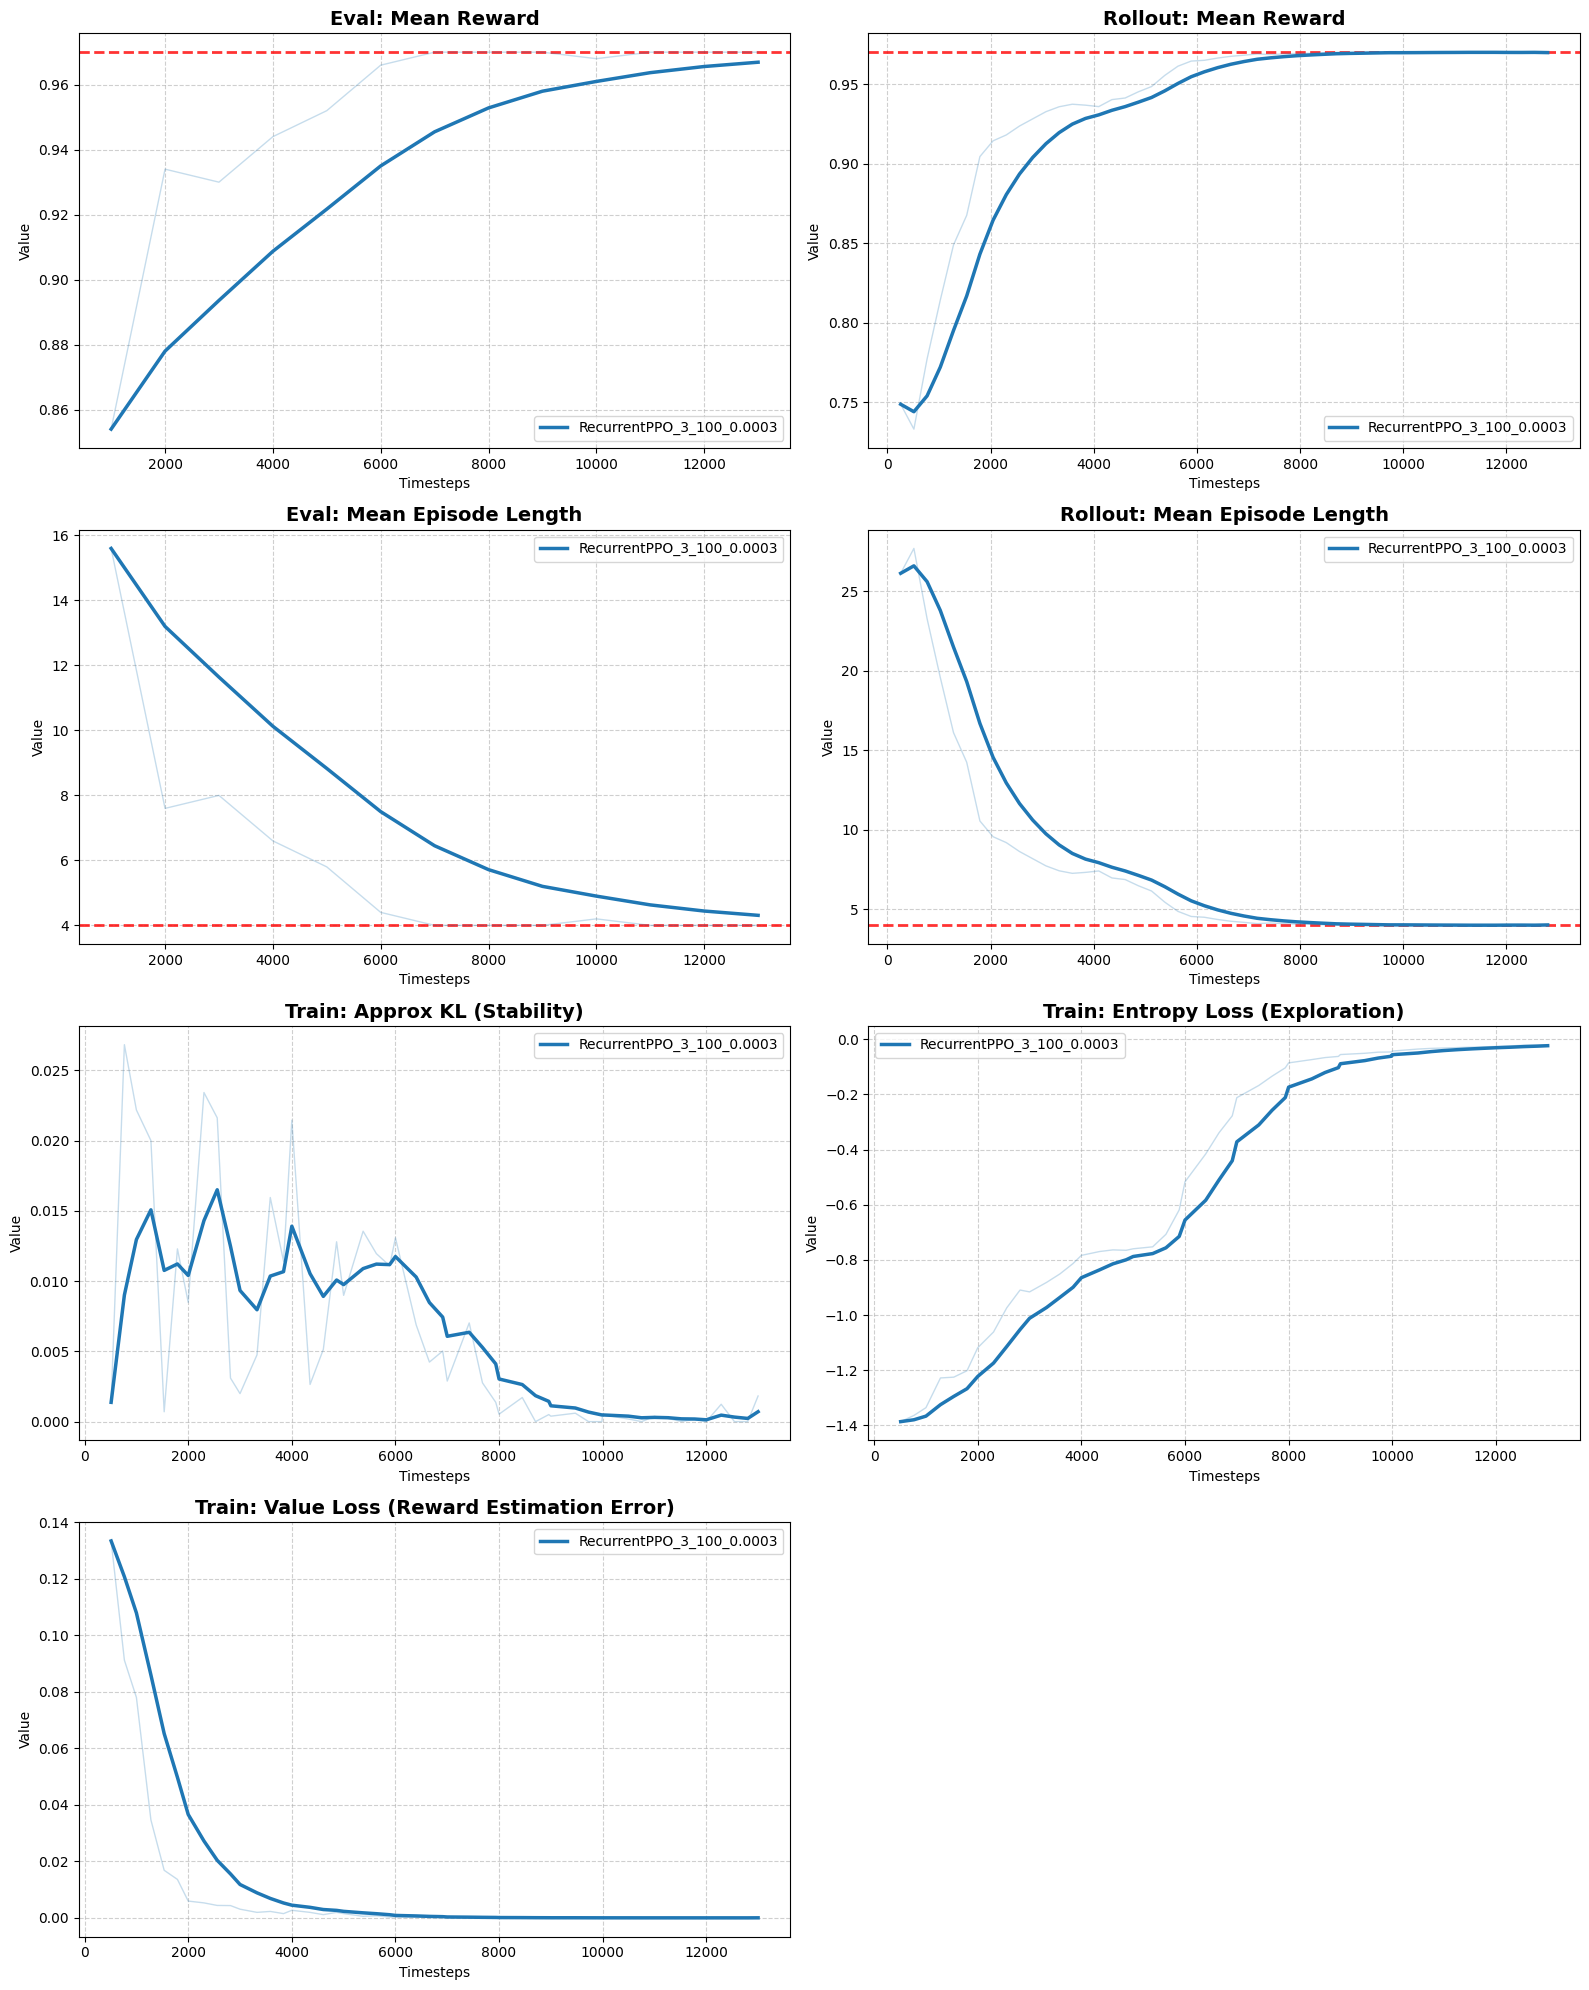

In [46]:
log_folder = f'./tensorboard_logs/RecurrentPPO_{3}_{100}_{0.0003}'
plot_tensorboard_logs([log_folder], 3, labels=[f'RecurrentPPO_{3}_{100}_{0.0003}'])

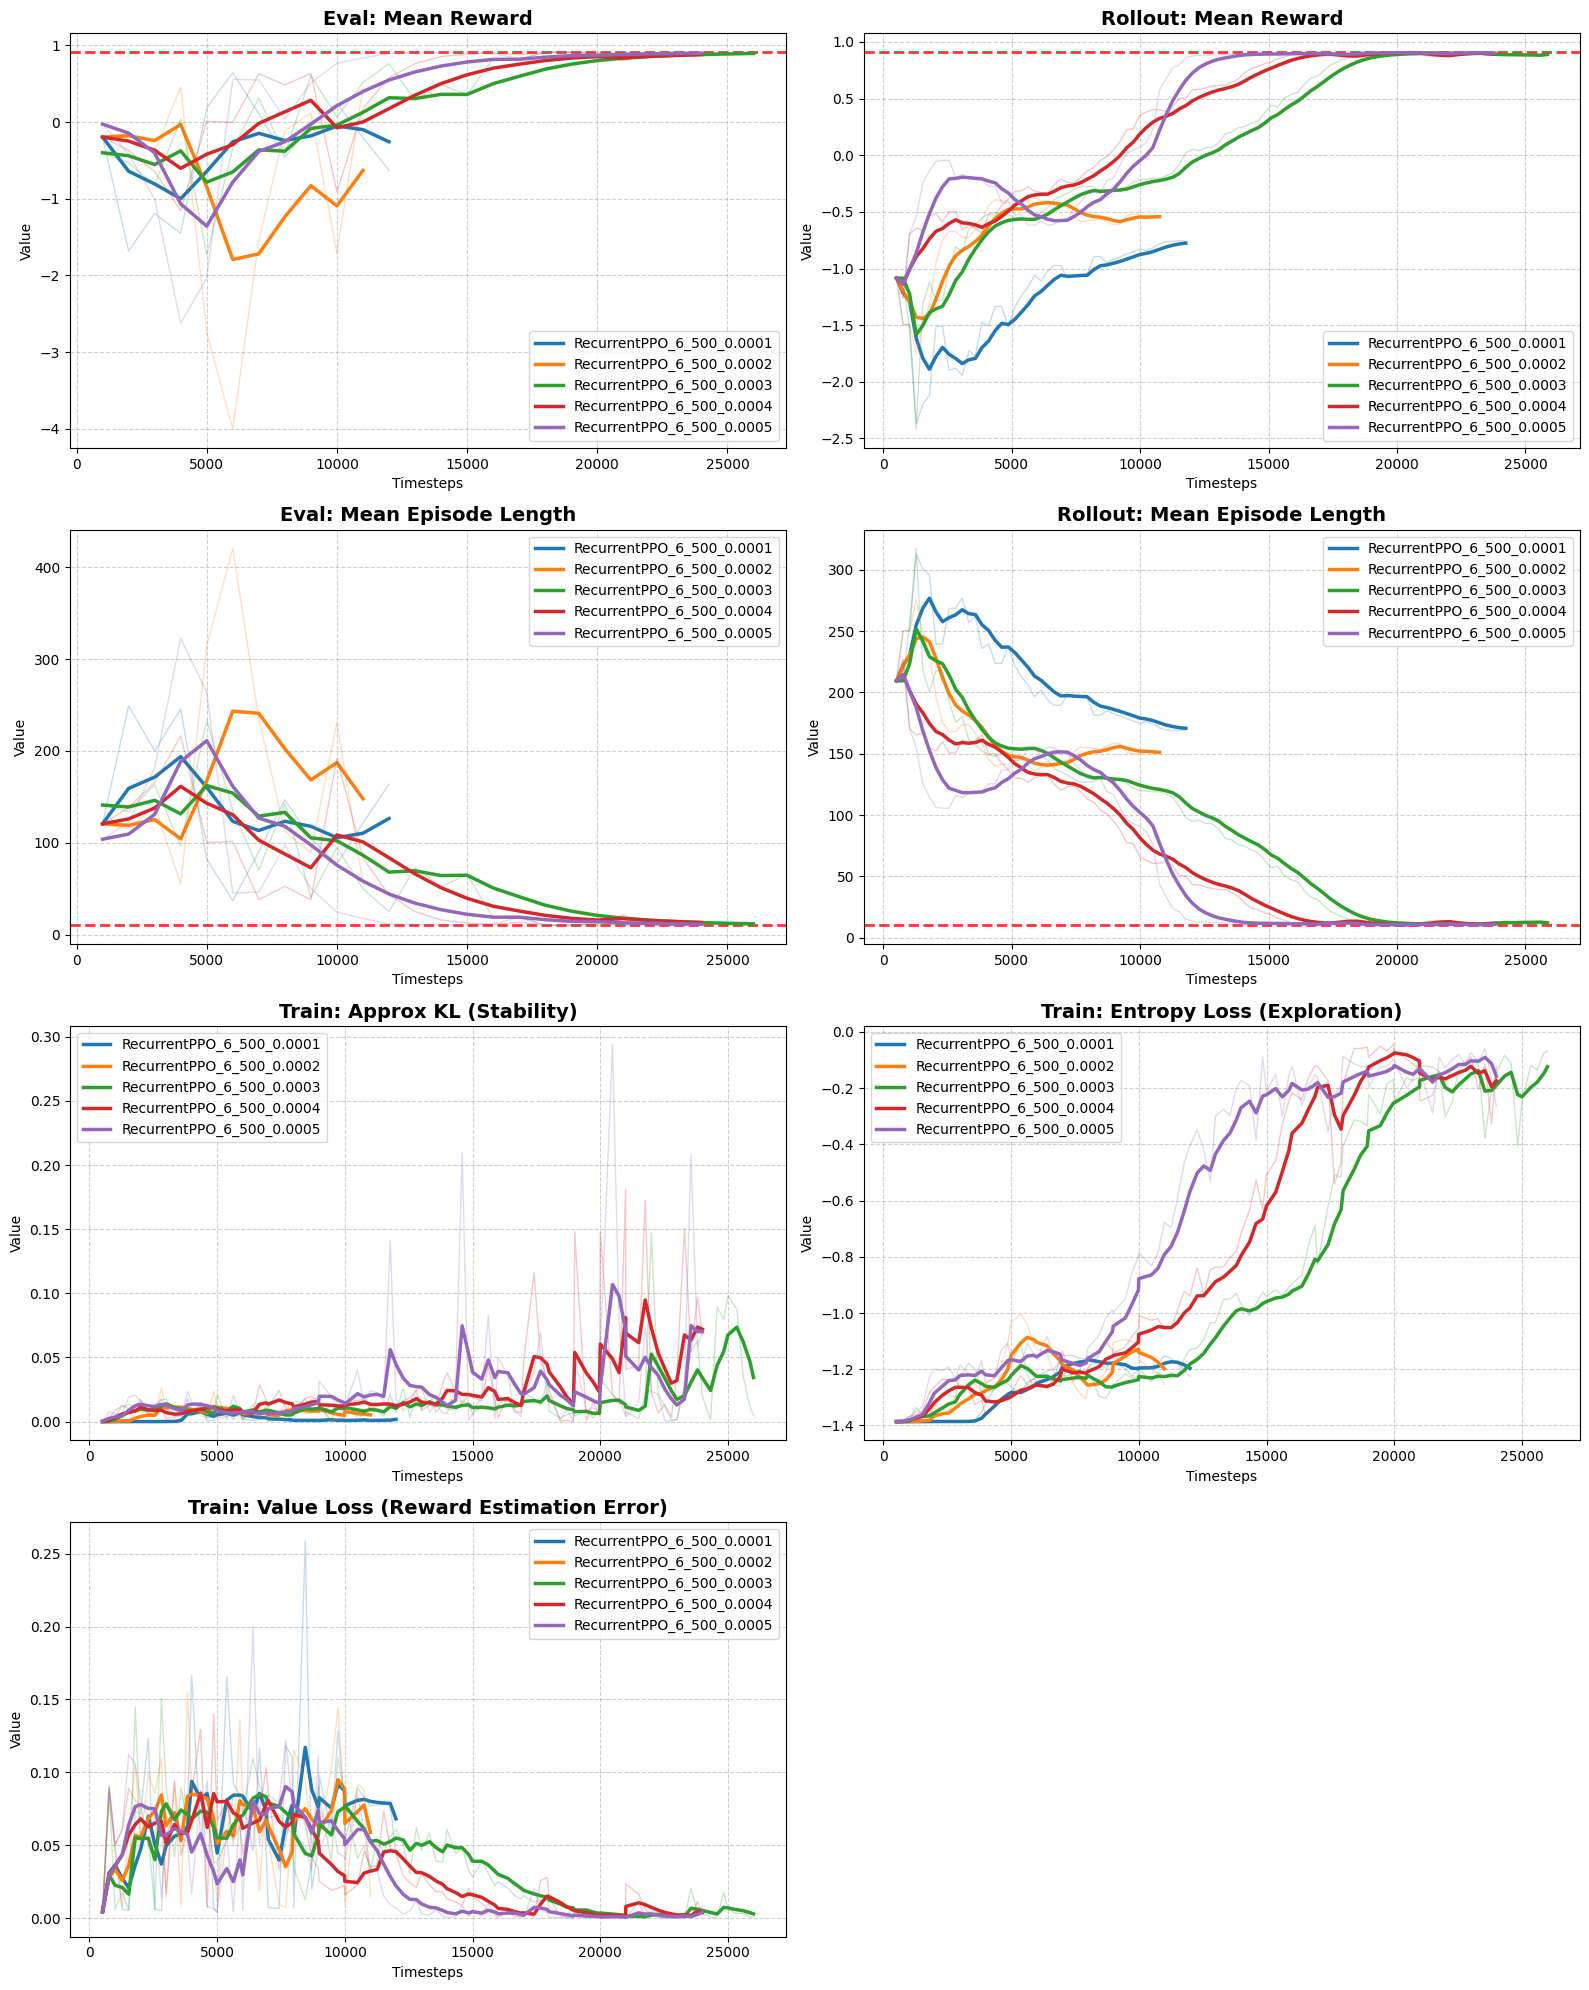

In [47]:
log_folder = []
labels = []
for lr in lr_6:
    log_folder.append(f'./tensorboard_logs/RecurrentPPO_{6}_{500}_{lr}')
    labels.append(f'RecurrentPPO_{6}_{500}_{lr}')
plot_tensorboard_logs(log_folder, 6, labels=labels)

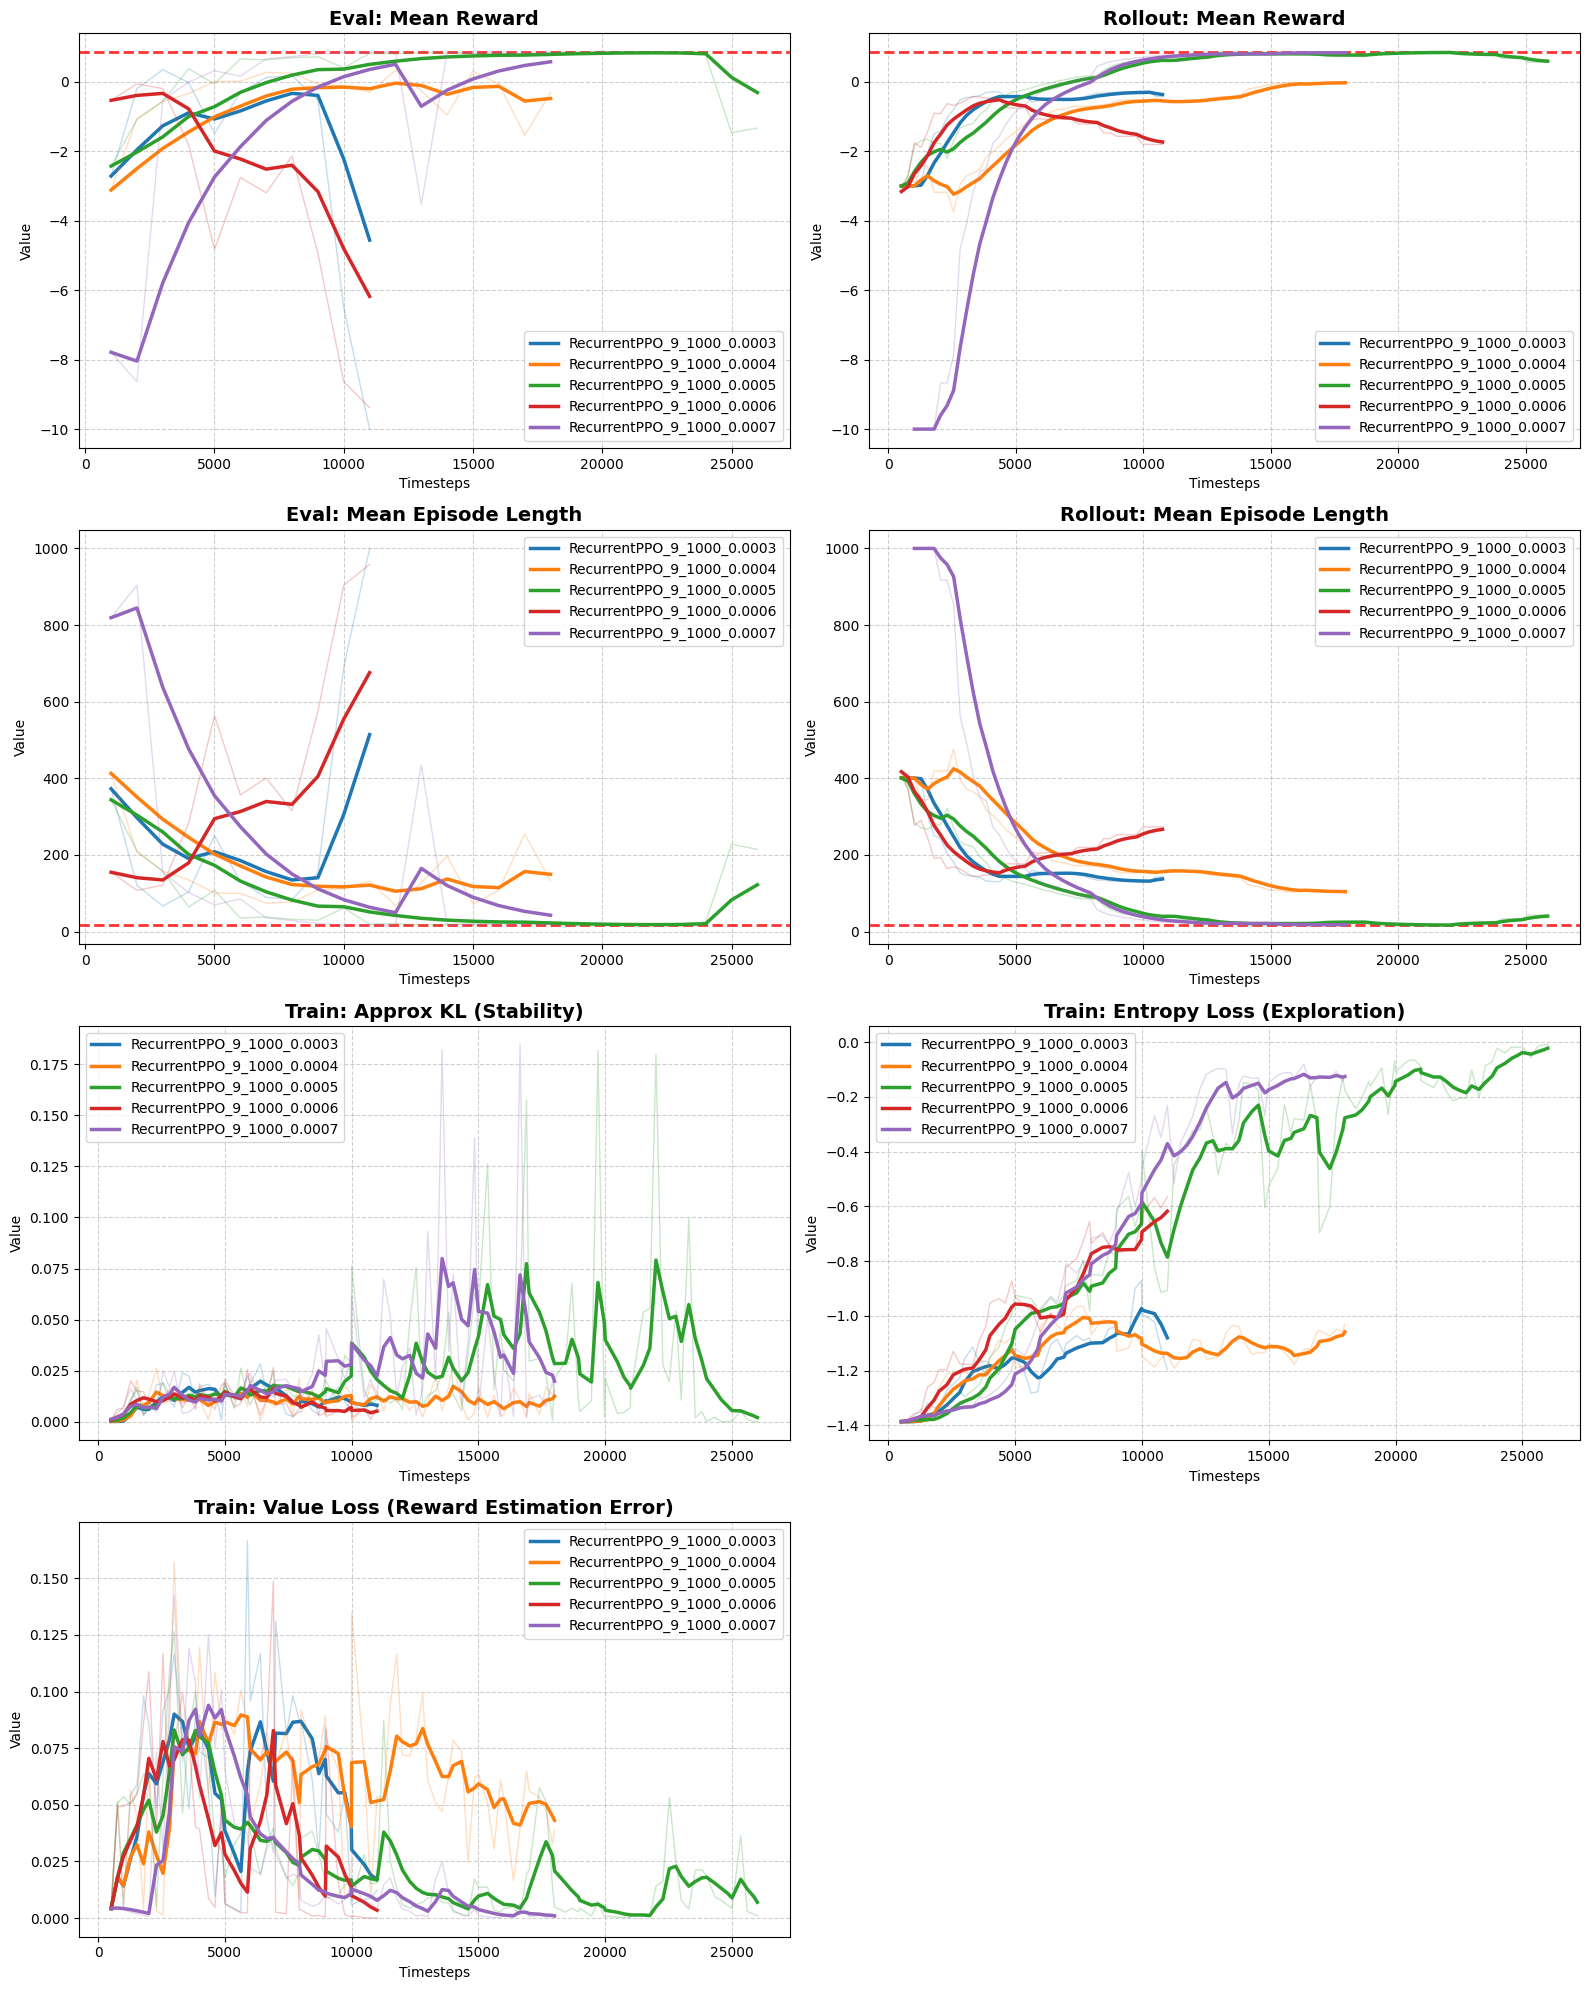

In [48]:
log_folder = []
labels = []
for lr in lr_9:
    log_folder.append(f'./tensorboard_logs/RecurrentPPO_{9}_{1000}_{lr}')
    labels.append(f'RecurrentPPO_{9}_{1000}_{lr}')
plot_tensorboard_logs(log_folder, 9, labels=labels)

## Collecting Trajectories

The next step is to collect a sufficient number of trajectories. I chose to gather 200 trajectories for the 3×3 maze, 1,500 for the 6×6 maze, and 3,000 for the 9×9 maze. During testing, I observed that the expert agent never deviated from the optimal trajectory. While, in theory, it is desirable for the agent to always reach the goal using the minimum possible number of steps, in practice I wanted the collected trajectories to exhibit slight variations. This makes the subsequent learning algorithms more robust by exposing them to a broader range of situations.

If the FSC or the Behavioral Cloning network is trained exclusively on perfect trajectories, it will have no notion of how to behave if, due to approximation errors, it ends up in a state outside the optimal path. Since the expert agent has never encountered such situations, the learned policy would likely fail to recover effectively. Furthermore, an FSC requires variability in the training data to accurately capture the dynamics of the environment and to learn a meaningful state compression. Otherwise, it would simply memorize a fixed sequence of actions (e.g., "move down, move down, move right..."), defeating the purpose of the model.

To address this issue, I introduced ε-greedy exploration during data collection. This occasionally forces the agent to deviate from the optimal trajectory, but because the expert policy has learned the maze so effectively, it is still able to recover and successfully reach the goal despite the injected randomness.

In [49]:
def collect_trajectories(model_path, grid_size, max_steps, n_episodes_to_collect):
    '''
    Collect and save trajectories from a trained RecurrentPPO model in the POMDPGridworld environment.

    Inputs:
    - model_path: Path to the trained RecurrentPPO model (should be a .zip file)
    - grid_size: Size of the gridworld (e.g., 3, 6, 9)
    - max_steps: Maximum steps per episode in the environment
    - n_episodes_to_collect: Number of episodes (trajectories) to collect

    Output:
    - True if trajectories were successfully collected and saved, False otherwise.
    - Trajectories are saved in a local file named 'oracle_dataset_{grid_size}x{grid_size}.pkl' in the './data/' directory.
    '''
    # 1. Load the model

    if model_path is not None:
        try:
            env = POMDPGridworld(size=grid_size, max_steps=max_steps)
            model = load_rppo(path=model_path)
        except Exception as e:
            raise RuntimeError(f"Error loading model from {model_path}: {e}")
            
    else:
        raise ValueError("No path provided for loading the model.")

    # 2. Play and save trajectories

    trajectories = []
    collected = 0

    while collected < n_episodes_to_collect:

        obs, _ = env.reset()

        lstm_states = None
        episode_starts = np.ones((1,), dtype=bool) 

        ep_obs = []
        ep_actions = []
        ep_rewards = []

        done = False
        truncated = False

        while not (done or truncated):
            ep_obs.append(obs)

            # 2. Request action from RecurrentPPO passing LSTM_states and Dones
            action, lstm_states = model.predict(obs, state=lstm_states, episode_start=episode_starts, deterministic=True)
            
            if random.random() < 0.25: 
                action = env.action_space.sample() 
            obs, reward, done, truncated, _ = env.step(action)
            episode_starts = np.zeros((1,), dtype=bool) # Immediately after the first action, set to False
            
            ep_actions.append(action)
            ep_rewards.append(reward)

        # 3. Save the data
        if done:
            trajectories.append({
                'observations': np.array(ep_obs),
                'actions': np.array(ep_actions),
                'rewards': np.array(ep_rewards),
                'length': len(ep_obs)
            })
            collected += 1
            if collected % 100 == 0:
                print(f"Collected {collected}/{n_episodes_to_collect} trajectories...")

    print(f"\nCollection completed for {grid_size}x{grid_size}. Average trajectory length: {np.mean([t['length'] for t in trajectories]):.2f} steps.")
    
    # Save the dataset in local file
    if trajectories:
        if not os.path.exists(f'./data/'):
            os.makedirs('./data', exist_ok=True)
        with open(f'./data/Trajectories_{grid_size}x{grid_size}.pkl', 'wb') as f:
            pickle.dump(trajectories, f)
    else:
        raise RuntimeError(f"No trajectories collected for size={grid_size}x{grid_size}. Dataset not saved.")

In [40]:
# IMPORTANT: I already tasted different combination and those are the ones that seem to work best for each size.
parameters = [
    (3, 100, 0.0003, 200),   # size, max_steps, learning_rate, verbose_level, number of trajectories to collect
    (6, 500, 0.0003, 1500),
    (9, 1000, 0.0005, 3000)
]

# This loop will go throw the list of parameters, train each agent, and plot the logs if requested. 
for size, max_steps, lr, n_episodes in parameters:

    # Collect trajectories for the trained model
    collect_trajectories(model_path=f'./models/RecurrentPPO_{size}_{max_steps}_{lr}/best_model.zip', grid_size=size, max_steps=max_steps, n_episodes_to_collect=n_episodes)
    print(f"Trajectories collected and saved for size={size}x{size}.")

Collected 100/200 trajectories...
Collected 200/200 trajectories...

Collection completed for 3x3. Average trajectory length: 5.33 steps.
Trajectories collected and saved for size=3x3.
Collected 100/1500 trajectories...
Collected 200/1500 trajectories...
Collected 300/1500 trajectories...
Collected 400/1500 trajectories...
Collected 500/1500 trajectories...
Collected 600/1500 trajectories...
Collected 700/1500 trajectories...
Collected 800/1500 trajectories...
Collected 900/1500 trajectories...
Collected 1000/1500 trajectories...
Collected 1100/1500 trajectories...
Collected 1200/1500 trajectories...
Collected 1300/1500 trajectories...
Collected 1400/1500 trajectories...
Collected 1500/1500 trajectories...

Collection completed for 6x6. Average trajectory length: 15.20 steps.
Trajectories collected and saved for size=6x6.
Collected 100/3000 trajectories...
Collected 200/3000 trajectories...
Collected 300/3000 trajectories...
Collected 400/3000 trajectories...
Collected 500/3000 traject

In [43]:

with open(f'./data/Trajectories_{3}x{3}.pkl', 'rb') as file:
    data = pickle.load(file)

    print(f"Dataset for size={3}x{3}:")
    print(f"Number of trajectories: {len(data)}")
    print(f"Average trajectory length: {np.mean([len(t['observations']) for t in data]):.2f} steps")
    print(f"Example trajectory (first 5 steps):")
    print(f"Observations: {data[0]['observations'][:5]}")
    print(f"Actions: {data[0]['actions'][:5]}")
    print(f"Rewards: {data[0]['rewards'][:5]}")


Dataset for size=3x3:
Number of trajectories: 200
Average trajectory length: 5.33 steps
Example trajectory (first 5 steps):
Observations: [[1 1 0 1]
 [0 0 1 1]
 [0 0 1 1]
 [1 0 0 0]
 [0 0 1 1]]
Actions: [2 2 1 2 1]
Rewards: [-0.01 -0.01 -0.01 -0.01  1.  ]


# Part 2: Train FSC

Before implementing the algorithm, it was necessary to understand the underlying model on which the project is based: the Finite State Controller (FSC).

An FSC is a finite-state machine that controls the behavior of an agent by maintaining an internal discrete memory. Unlike purely combinational logic, whose output depends only on the current input, an FSC also depends on its internal state, allowing past information to influence future decisions. This characteristic makes FSCs particularly suitable for Partially Observable Markov Decision Processes (POMDPs), where the current observation alone is generally insufficient to determine the optimal action. Instead, the controller maintains a compact memory of previous interactions with the environment, enabling it to infer hidden information and make informed decisions.

Before implementing the model, several fundamental design questions had to be addressed.

**What is the objective of the FSC?**

The goal of the FSC is to learn an interpretable generative model that explains the trajectories collected from the expert PPO policy. Given the sequence of observations y encountered by the expert while navigating the maze, the FSC should generate the same sequence of actions a with high probability.

Conceptually, the FSC acts as a cognitive summary of the expert policy. At every time step, it combines the current observation with its internal memory state to determine both the next action and the next internal state. Rather than memorizing trajectories, the controller attempts to capture the decision-making process followed by the expert.

**FSC Parameters**

An FSC is completely defined by three integer dimensions:

M: number of discrete internal memory states;
A: number of possible actions;
Y: number of possible observations.

The model contains three groups of learnable parameters, which are initialized from a zero-centered Gaussian distribution.

**Initial state distribution**

The initial memory distribution is represented by a vector 
$$
\theta^{(\rho)} \in \mathbb{R}^{M},
$$
which defines
$$
\rho(m_0),
$$
namely the probability that the controller starts in each internal state at the beginning of an episode.

**Emission policy**

The policy parameters are stored in a matrix
$$
\theta^{(\pi)} \in \mathbb{R}^{A \times M},
$$
which defines the conditional distribution
$$
\pi(a_t \mid m_t),
$$
representing the probability of selecting action $\alpha_t$ given the current internal state.

**Internal transition model**

The internal dynamics are encoded by a four-dimensional tensor
$$
\theta^{(g)} \in \mathbb{R}^{M \times M \times A \times Y},
$$
which represents
$$
g(m_{t+1}\mid m_t,a_t,y_t),
$$
that is, the probability of transitioning to a new internal state after executing action $\alpha_t$ and receiving observation $y_t$.

Although this representation may initially appear complex, an FSC contains relatively few trainable parameters. In practice, the hyperparameter that has the greatest impact on performance is the number of internal states M, which determines the memory capacity of the controller and is therefore the main parameter investigated throughout this work.

**Learning Objective**

The FSC must be trained to reproduce the expert demonstrations as accurately as possible. Consequently, a likelihood function is required to measure how well the controller explains the collected trajectories.

Given a trajectory

$$
T=(y_{0:T},a_{0:T}),
$$

the probability assigned by the FSC is obtained by marginalizing over every possible sequence of internal memory states:

$$
P(a_{0:T}\mid y_{0:T})
=
\sum_{m_{0:T+1}}
\rho(m_0)
\prod_{t=0}^{T}
\pi(a_t\mid m_t)
g(m_{t+1}\mid m_t,a_t,y_t).
$$

The model is trained by minimizing the average Negative Log-Likelihood (NLL) over all trajectories in the dataset:

$$
\mathcal{L}
=
-
\frac{1}{N}
\sum_{k=1}^{N}
\log
P\left(
a^{(k)}_{0:T_k}
\mid
y^{(k)}_{0:T_k}
\right).
$$

Minimizing this objective encourages the FSC to assign increasingly higher probability to the expert demonstrations.

**Efficient Likelihood Computation**

A direct evaluation of the previous summation is computationally infeasible. Since every possible sequence of internal states must be considered, the computational cost grows exponentially with the trajectory length.

To avoid this issue, the likelihood is computed using the forward algorithm, which recursively propagates a forward probability vector.

Define the forward vector

$$
\alpha_t \in \mathbb{R}^{M},
$$

whose i-th component represents the joint probability of observing the trajectory up to time t while ending in internal state i.

At the beginning of each trajectory,

$$
\alpha_0=\rho.
$$

At every time step, the expert dataset already specifies both the executed action $\alpha_t$ and the received observation $y_t$. 
Therefore, instead of using the complete emission matrix and transition tensor, only the relevant slices need to be extracted.

The emission matrix yields the vector

$$
E_t=\pi(a_t\mid \cdot),
$$

while the transition tensor yields the matrix

$$
T_t=g(\cdot\mid\cdot,a_t,y_t).
$$

The forward recursion then becomes

$$
\alpha_{t+1}
=
T_t
\left(
\alpha_t
\odot
E_t
\right),
$$

where:

+ ⊙ denotes the element-wise (Hadamard) product;
+ matrix multiplication propagates the resulting probabilities to the next internal state.

After processing the final time step, the likelihood of the entire trajectory is simply obtained by summing the components of the final forward vector:

$$
P(a_{0:T}\mid y_{0:T})
=
\sum_i
\alpha_{T+1}^{(i)}.
$$

This dynamic programming formulation reduces the computational complexity from exponential to linear in the trajectory length, making gradient-based optimization of the FSC computationally tractable.

In [50]:
class FSC(nn.Module):
    """
    Finite State Controller parametrizied with pytorch. 
    The rough parameters (theta_*) are free in R.
    The log-probabilities are obtained via F.log_softmax, which:
    - ensures stochasticity (values sum to 1)
    - maintains the computational graph for autograd

    Normalization axes for log-softmax:
    theta_pi  (M,)         → dim=0  → rho(m_0)         sum over M
    theta_pie (A, M)       → dim=0  → pi(a|m)           sum over A for each m
    theta_g   (M, M, A, Y) → dim=0  → g(m'|m, a, y)    sum over M_next for each (m,a,y)

    Input:
    - M: Number of internal states (memory states)
    - A: Number of actions
    - Y: Number of possible observations

    Output:
    - nll_trajectory(traj_a, traj_y): Computes the Negative Log-Likelihood of a given 
      trajectory of actions and observations, which can be used for training the FSC via gradient descent
    """

    def __init__(self, M: int, A: int, Y: int):
        super().__init__()
        self.M = M
        self.A = A
        self.Y = Y
        self.theta_pi  = nn.Parameter(torch.randn(M))
        self.theta_pie = nn.Parameter(torch.randn(A, M))
        self.theta_g   = nn.Parameter(torch.randn(M, M, A, Y))

    def nll_trajectory(self, traj_a: torch.Tensor, traj_y: torch.Tensor) -> torch.Tensor:
        """
        Computes the Negative Log-Likelihood (NLL) of a single trajectory using the forward algorithm (alpha recursion).

        Input:
        - traj_a : LongTensor (T,) - actions (0..A-1)
        - traj_y : LongTensor (T,) - observation indices (0..Y-1)
        
        Output:
        - scalar Tensor - NLL of the trajectory (with autograd graph)
        """
        log_rho = F.log_softmax(self.theta_pi,  dim=0)   # (M,)
        log_pie = F.log_softmax(self.theta_pie,  dim=0)   # (A, M)
        log_g   = F.log_softmax(self.theta_g,    dim=0)   # (M, M, A, Y)

        log_alpha = log_rho  # (M,)

        for a_t, y_t in zip(traj_a, traj_y):
            log_E_t   = log_pie[a_t]               # (M,)        – emission (action)
            log_T_t   = log_g[:, :, a_t, y_t]     # (M_next, M_prev) – transition
            # Broadcasting: (M_next, M_prev) + (1, M_prev) + (1, M_prev)
            inside    = log_T_t + log_alpha.unsqueeze(0) + log_E_t.unsqueeze(0)
            log_alpha = torch.logsumexp(inside, dim=1)  # (M_next,)

        return -torch.logsumexp(log_alpha, dim=0)  # scalar

def obs_to_index(obs):
    '''
    Converts a binary observation (array of 4 bits) into an integer index (0 to 15).

    Input:
    - obs: A binary array of shape (4,) representing the presence of walls

    Output:
    - An integer index corresponding to the binary observation
    '''
    return int("".join(obs.astype(str)), 2)

In [51]:
def train_fsc(dataset,
                size: int,
                M: int = 8,
                A: int = 4,
                Y: int = 16,
                n_restarts: int = 5,
                max_epochs: int = 500,
                lr: float = 1e-2,
                patience: int = 50,
                batch_size: int = 64,
                verbose: bool = True,
                ):
    """
    Train an FSC via NLL minima + Adam + random restarts.
    At each restart, the parameters are re-initialized with torch.randn.
    Early stopping is triggered if the loss does not decrease by at least 1e-4
    for `patience` consecutive epochs.
    Returns the FSC with the lowest NLL among all restarts.

    Input:
    - dataset: List of trajectories, where each trajectory is a dict with keys 'observations', 'actions', 'rewards'
    - size: Size of the gridworld (used for naming the saved model)
    - M: Number of internal states (memory states)
    - A: Number of actions
    - Y: Number of possible observations
    - n_restarts: Number of random restarts for training
    - max_epochs: Maximum number of epochs per restart
    - lr: Learning rate for Adam optimizer
    - patience: Number of epochs to wait for improvement before early stopping
    - batch_size: Number of trajectories per training batch
    - verbose: If True, prints training progress and final NLL

    Output:
    - best_fsc: The FSC instance with the lowest NLL found across all restarts
    - best_loss: The lowest NLL achieved
    - history: A list of lists, where each inner list contains the epoch losses for a restart
    """
    
    # Prepare the dataset: binary observations to integer indices (0–15)
    traj_a_list = [torch.tensor(t['actions'], dtype=torch.long) for t in dataset]
    traj_y_list = [
        torch.tensor([obs_to_index(o) for o in t['observations']], dtype=torch.long)
        for t in dataset
    ]
    N = len(traj_a_list)

    best_loss       = float('inf')
    best_state_dict = {}
    history         = []  # history[r] = list of losses per epoch for restart r

    for restart in range(n_restarts):
        fsc       = FSC(M, A, Y)
        optimizer = torch.optim.Adam(fsc.parameters(), lr=lr)

        no_improve      = 0
        best_epoch_loss = float('inf')
        epoch_losses    = []

        for epoch in range(max_epochs):
            # Shuffle indices to create random mini-batches
            indices = torch.randperm(N)
            epoch_nll_sum = 0.0

            for start in range(0, N, batch_size):
                batch_idx = indices[start : start + batch_size]

                optimizer.zero_grad()

                nll_list = [
                    fsc.nll_trajectory(traj_a_list[int(i)], traj_y_list[int(i)])
                    for i in batch_idx
                ]
                loss = torch.stack(nll_list).mean()

                loss.backward()
                # Gradient clipping: prevent gradient explosion on long trajectories
                torch.nn.utils.clip_grad_norm_(fsc.parameters(), max_norm=5.0)
                optimizer.step()

                epoch_nll_sum += loss.item() * len(batch_idx)

            epoch_loss = epoch_nll_sum / N
            epoch_losses.append(epoch_loss)

            # Early stopping
            if epoch_loss < best_epoch_loss - 1e-4:
                best_epoch_loss = epoch_loss
                no_improve      = 0
            else:
                no_improve += 1

            if no_improve >= patience:
                break

        history.append(epoch_losses)

        if verbose:
            print(f"Restart {restart+1}/{n_restarts} | Epoch: {len(epoch_losses):4d} | NLL: {best_epoch_loss:.4f}")

        if best_epoch_loss < best_loss:
            best_loss       = best_epoch_loss
            best_state_dict = {k: v.clone().detach() for k, v in fsc.state_dict().items()}

    # Recreate the FSC and load the parameters from the best restart
    best_fsc = FSC(M, A, Y)
    best_fsc.load_state_dict(best_state_dict)

    if not os.path.exists(f'./models/FSC_{size}/'):
        os.makedirs(f'./models/FSC_{size}', exist_ok=True)
    torch.save(best_fsc.state_dict(), f'./models/FSC_{size}/FSC_{M}states.pt')

    if verbose:
        print(f"\nBest NLL: {best_loss:.4f}\n")

    return best_fsc, best_loss, history

def load_fsc(path, M):
    '''
    Loads a trained FSC from the specified path.

    Input:
    - path: The file path to the saved FSC model (e.g., './models/FSC_3/FSC_8states.pt')
    - M: The number of internal states (memory states) used in the FSC architecture

    Output:
    - model: The loaded FSC model.
    '''
    fsc_loaded = FSC(M=M, A=4, Y=16)
    fsc_loaded.load_state_dict(torch.load(path, weights_only=True))
    fsc_loaded.eval()
    return fsc_loaded

### Train the FSCs

**Selecting the Number of Internal States**

As discussed in the previous section, the number of internal memory states M is the hyperparameter that has the greatest impact on the performance of an FSC. Consequently, different values of M were evaluated for each maze size to investigate the trade-off between model capacity and training complexity.

For the 3×3 maze, nine configurations were considered, with

$$
M \in \{1,2,3,4,5,6,7,8,9\}.
$$

Since this environment is relatively simple, evaluating a wide range of values also made it possible to investigate how the FSC behaves when the number of internal states approaches the number of cells in the maze.

For the 6×6 and 9×9 mazes, a geometric progression of memory sizes was adopted:

$$
M \in \{1,2,4,8,16\}.
$$

This scaling strategy was chosen to evaluate whether doubling the number of internal states produces a proportional reduction in the Negative Log-Likelihood (NLL), or whether the performance improvements gradually diminish while training costs continue to increase.

=== Training FSC for size=3x3 with M=1 ===

Restart 1/5 | Epoch:   84 | NLL: 5.6809
Restart 2/5 | Epoch:   63 | NLL: 5.6808
Restart 3/5 | Epoch:  158 | NLL: 5.6809
Restart 4/5 | Epoch:  169 | NLL: 5.6809
Restart 5/5 | Epoch:  105 | NLL: 5.6810

Best NLL: 5.6808

=== Training FSC for size=3x3 with M=2 ===

Restart 1/5 | Epoch:  500 | NLL: 3.7228
Restart 2/5 | Epoch:  500 | NLL: 3.7238
Restart 3/5 | Epoch:  500 | NLL: 3.7238
Restart 4/5 | Epoch:  500 | NLL: 3.7228
Restart 5/5 | Epoch:  500 | NLL: 3.7242

Best NLL: 3.7228

=== Training FSC for size=3x3 with M=3 ===

Restart 1/5 | Epoch:  500 | NLL: 3.6755
Restart 2/5 | Epoch:  500 | NLL: 3.6514
Restart 3/5 | Epoch:  500 | NLL: 3.6732
Restart 4/5 | Epoch:  500 | NLL: 3.6527
Restart 5/5 | Epoch:  421 | NLL: 3.6742

Best NLL: 3.6514

=== Training FSC for size=3x3 with M=4 ===

Restart 1/5 | Epoch:  500 | NLL: 3.6155
Restart 2/5 | Epoch:  500 | NLL: 3.6067
Restart 3/5 | Epoch:  500 | NLL: 3.5996
Restart 4/5 | Epoch:  500 | NLL: 3.6176
Restart

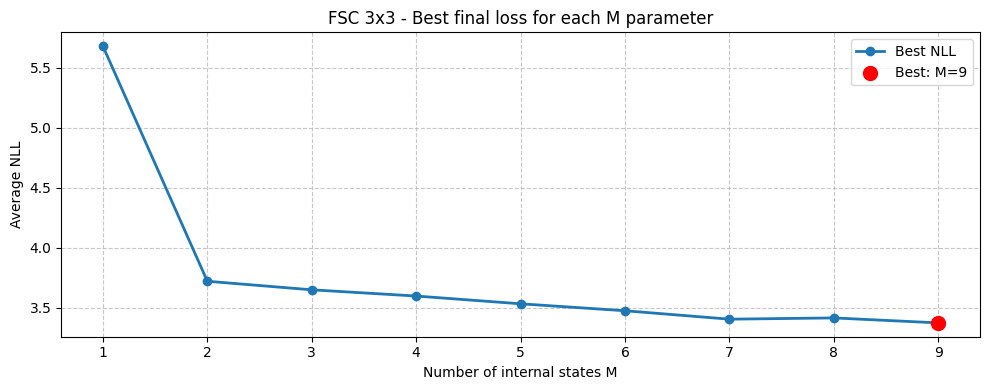

In [51]:
parameters = [
    (3, "./data/Trajectories_3x3.pkl")
]
parameters_fsc_3 = [
    (1,2,3,4,5,6,7,8,9), # M for 3x3
]

for (size, path), M_values in zip(parameters, parameters_fsc_3):

    all_fsc = [] # Save all models
    all_losses = [] # save all best losses for each M
    all_histories = [] # Save all training histories for each M

    for M in M_values:
        print(f"=== Training FSC for size={size}x{size} with M={M} ===\n")
        with open(path, 'rb') as f:
            dataset = pickle.load(f)
        fsc, best_loss, history = train_fsc(dataset,
                                        size = size,
                                        M = M,
                                        A = 4, # Number of actions
                                        Y = 16, # Number of possible observations 
                                        n_restarts = 5,
                                        max_epochs = 500,
                                        lr = 1e-2, # Default learning rate
                                        patience = 30,
                                        batch_size = 32,
                                        verbose = True,
                                        )
        
        all_losses.append(best_loss)
        all_histories.append(history)
        all_fsc.append(fsc)
    
    plot_fsc_training_history(size, M_values, all_losses)

Dataset caricato: 1500 traiettorie
Test con M=1 stati interni...
Restart 1/5 | Epoche:   44 | NLL: 17.1181
Restart 2/5 | Epoche:   35 | NLL: 17.1186
Restart 3/5 | Epoche:   48 | NLL: 17.1183
Restart 4/5 | Epoche:   44 | NLL: 17.1180
Restart 5/5 | Epoche:   51 | NLL: 17.1181

Miglior NLL finale: 17.1180
Test con M=2 stati interni...
Restart 1/5 | Epoche:  178 | NLL: 13.3081
Restart 2/5 | Epoche:  206 | NLL: 13.3077
Restart 3/5 | Epoche:  185 | NLL: 13.3081
Restart 4/5 | Epoche:  138 | NLL: 13.3088
Restart 5/5 | Epoche:  185 | NLL: 13.3077

Miglior NLL finale: 13.3077
Test con M=4 stati interni...
Restart 1/5 | Epoche:  240 | NLL: 11.8922
Restart 2/5 | Epoche:  306 | NLL: 11.6482
Restart 3/5 | Epoche:  280 | NLL: 12.0430
Restart 4/5 | Epoche:  264 | NLL: 11.8370
Restart 5/5 | Epoche:  257 | NLL: 11.7329

Miglior NLL finale: 11.6482
Test con M=8 stati interni...
Restart 1/5 | Epoche:  348 | NLL: 10.8645
Restart 2/5 | Epoche:  414 | NLL: 10.9206
Restart 3/5 | Epoche:  500 | NLL: 10.9346
Re

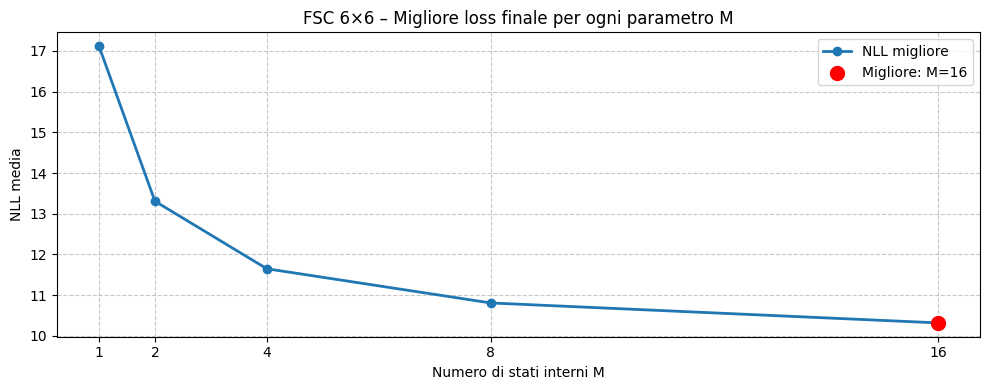

In [ ]:
parameters = [
    (6, "./data/Trajectories_6x6.pkl")
]
parameters_fsc_6 = [
    (1,2,4,8,16), # M for 6x6
]

for (size, path), M_values in zip(parameters, parameters_fsc_6):

    all_fsc = [] # Save all models
    all_losses = [] # save all best losses for each M
    all_histories = [] # Save all training histories for each M

    for M in M_values:
        print(f"=== Training FSC for size={size}x{size} with M={M} ===\n")
        with open(path, 'rb') as f:
            dataset = pickle.load(f)
        fsc, best_loss, history = train_fsc(dataset,
                                        size = size,
                                        M = M,
                                        A = 4, # Number of actions
                                        Y = 16, # Number of possible observations 
                                        n_restarts = 5,
                                        max_epochs = 500,
                                        lr = 1e-2, # Default learning rate
                                        patience = 30,
                                        batch_size = 32,
                                        verbose = True,
                                        )
        
        all_losses.append(best_loss)
        all_histories.append(history)
        all_fsc.append(fsc)
    
    plot_fsc_training_history(size, M_values, all_losses)

Dataset caricato: 5000 traiettorie
Test con M=1 stati interni...
Restart 1/5 | Epoche:   33 | NLL: 28.3208
Restart 2/5 | Epoche:   35 | NLL: 28.3214
Restart 3/5 | Epoche:   34 | NLL: 28.3211
Restart 4/5 | Epoche:   33 | NLL: 28.3210
Restart 5/5 | Epoche:   36 | NLL: 28.3209

Miglior NLL finale: 28.3208
Test con M=2 stati interni...
Restart 1/5 | Epoche:   58 | NLL: 22.1814
Restart 2/5 | Epoche:  113 | NLL: 22.1796
Restart 3/5 | Epoche:   83 | NLL: 22.1807
Restart 4/5 | Epoche:  105 | NLL: 22.1800
Restart 5/5 | Epoche:  101 | NLL: 22.1804

Miglior NLL finale: 22.1796
Test con M=4 stati interni...
Restart 1/5 | Epoche:  208 | NLL: 20.2322
Restart 2/5 | Epoche:  270 | NLL: 20.7704
Restart 3/5 | Epoche:  257 | NLL: 19.9595
Restart 4/5 | Epoche:  212 | NLL: 20.3430
Restart 5/5 | Epoche:  135 | NLL: 20.1654

Miglior NLL finale: 19.9595
Test con M=8 stati interni...
Restart 1/5 | Epoche:  230 | NLL: 18.8615
Restart 2/5 | Epoche:  232 | NLL: 18.6507
Restart 3/5 | Epoche:  329 | NLL: 18.6847
Re

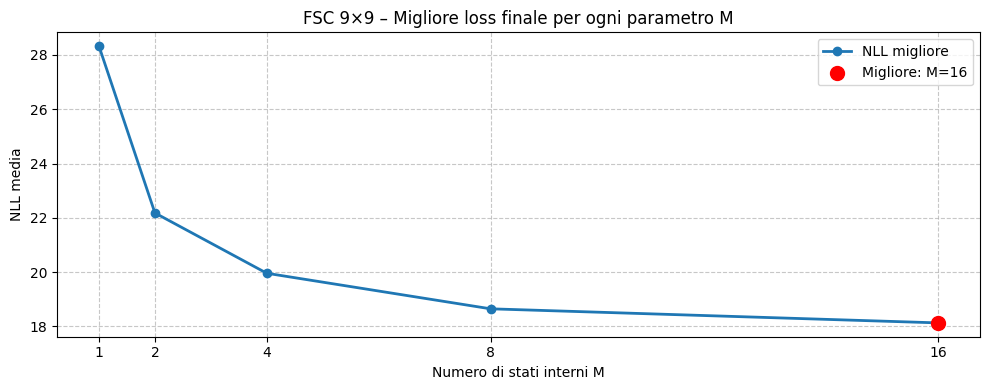

In [ ]:
parameters = [
    (9, "./data/Trajectories_9x9.pkl")
]
parameters_fsc_9 = [
    (1,2,4,8,16), # M for 9x9
]

for (size, path), M_values in zip(parameters, parameters_fsc_9):

    all_fsc = [] # Save all models
    all_losses = [] # save all best losses for each M
    all_histories = [] # Save all training histories for each M

    for M in M_values:
        print(f"=== Training FSC for size={size}x{size} with M={M} ===\n")
        with open(path, 'rb') as f:
            dataset = pickle.load(f)
        fsc, best_loss, history = train_fsc(dataset,
                                        size = size,
                                        M = M,
                                        A = 4, # Number of actions
                                        Y = 16, # Number of possible observations 
                                        n_restarts = 5,
                                        max_epochs = 500,
                                        lr = 1e-2, # Default learning rate
                                        patience = 30,
                                        batch_size = 32,
                                        verbose = True,
                                        )
        
        all_losses.append(best_loss)
        all_histories.append(history)
        all_fsc.append(fsc)
    
    plot_fsc_training_history(size, M_values, all_losses)

**Experimental Results**

After training all FSC configurations on each maze, the final NLL values were compared.

For the 3×3 maze, the transition from one to two internal states produced the largest improvement, reducing the NLL by approximately one third. This behavior is expected because a controller with only a single internal state cannot distinguish between the two fundamental navigation strategies required in the environment—moving right and moving down. Introducing a second memory state allows the controller to represent these two behaviors separately, resulting in a substantial increase in modeling accuracy.

Beyond two internal states, each additional memory state further reduced the NLL, although the improvements became progressively smaller and no significant performance jumps were observed.

The 6×6 and 9×9 mazes exhibited a similar trend. Again, the largest performance gain occurred when increasing the controller from one to two internal states. Increasing the memory size to four states yielded a further improvement, although considerably smaller than the initial one. Finally, moving from eight to sixteen internal states produced only marginal reductions in NLL.

These results indicate that increasing the memory capacity of the FSC exhibits diminishing returns. While a larger number of internal states consistently improves the likelihood of the expert trajectories, the additional gains become increasingly small relative to the extra computational cost required for training.

Based on these observations, the subsequent experiments were performed using four internal states. This choice represents a good compromise between model complexity and performance. Moreover, four memory states naturally match the four possible movement actions available in the maze (up, down, left, and right), allowing the controller to learn an expressive yet compact internal representation while achieving consistently low NLL values across all three environments.

### A look inside the FSC brain

Among the various differences highlighted between the proposed approach and conventional reinforcement learning methods based on neural networks, the most significant advantage of the Finite State Controller is its interpretability.

An FSC consists of a finite set of internal memory states, a transition model that updates the controller's belief about its current internal state based on the observed interaction with the environment, and an emission policy that assigns a probability distribution over actions given the current internal state. Because each component has a clear probabilistic interpretation, the decision-making process is transparent and can be analyzed directly.

Unlike neural network policies, whose internal representations are often difficult to interpret, an FSC makes it possible to understand why a particular action is selected, with what probability it is chosen, and how the controller's internal belief evolves throughout an episode. This provides valuable insight into the reasoning process followed by the agent rather than treating it as a black box.

In addition to visualizing the controller as a finite-state graph, the learned transition and belief matrices can be used to simulate an episode step by step. At each time step, the controller's belief over the internal states can be computed and displayed, allowing the evolution of the agent's internal memory to be observed in real time as it interacts with the environment. This level of transparency makes it considerably easier to analyze, debug, and explain the behavior learned by the controller.


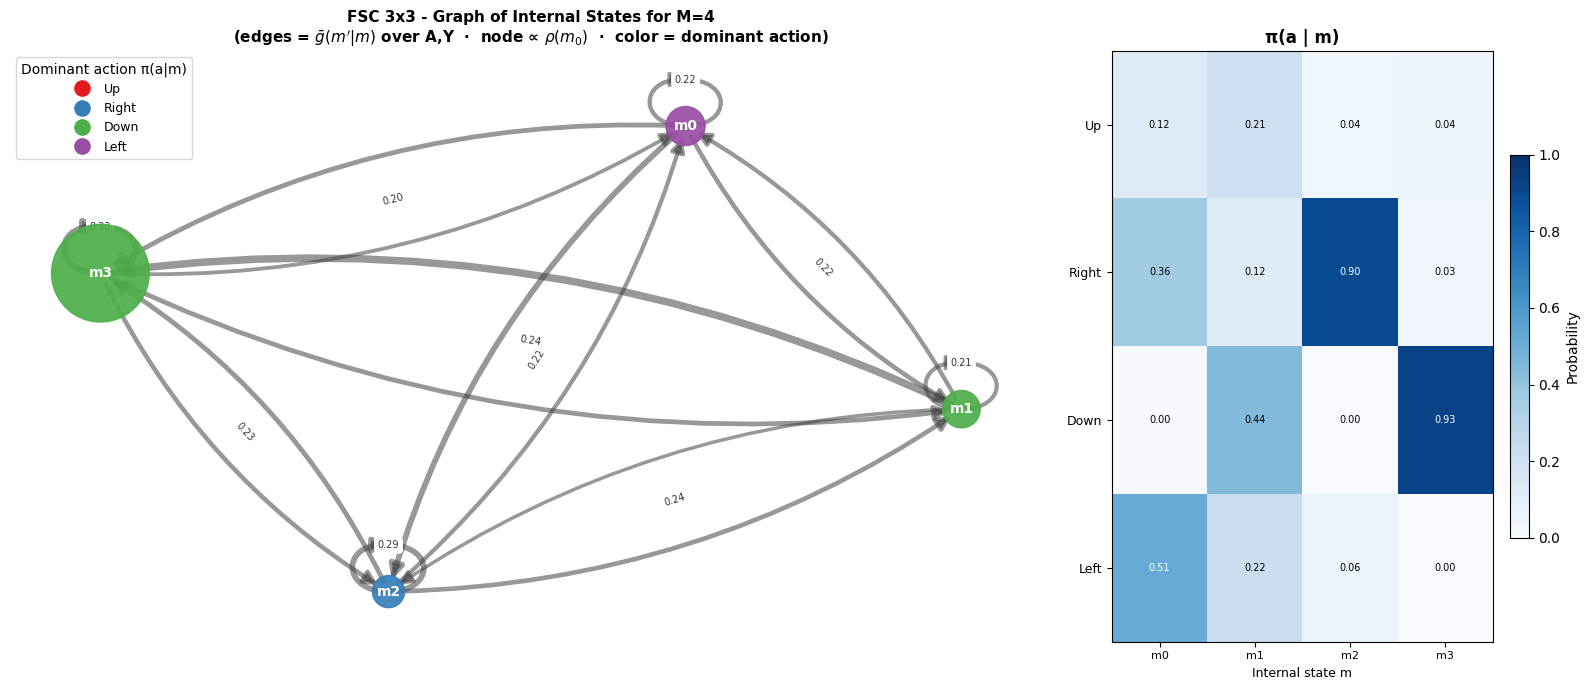

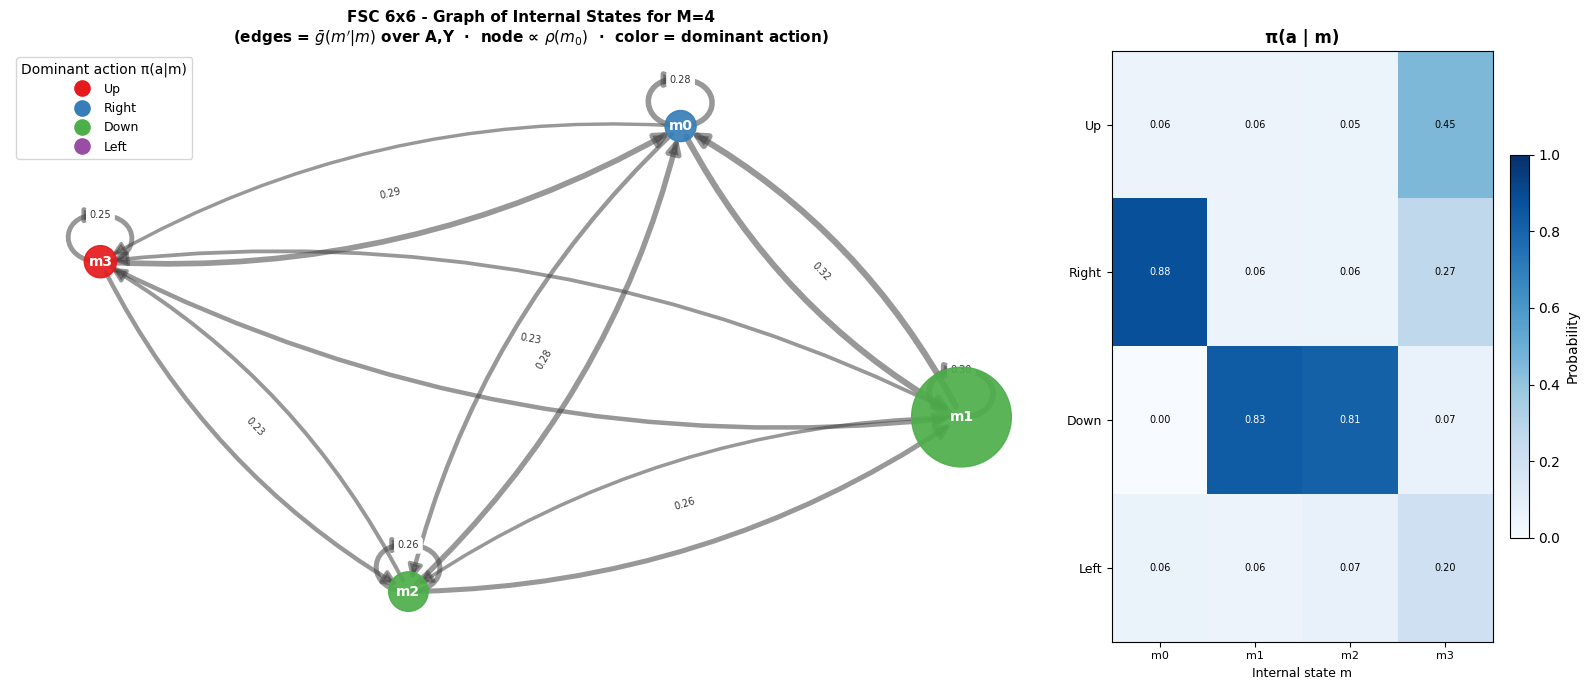

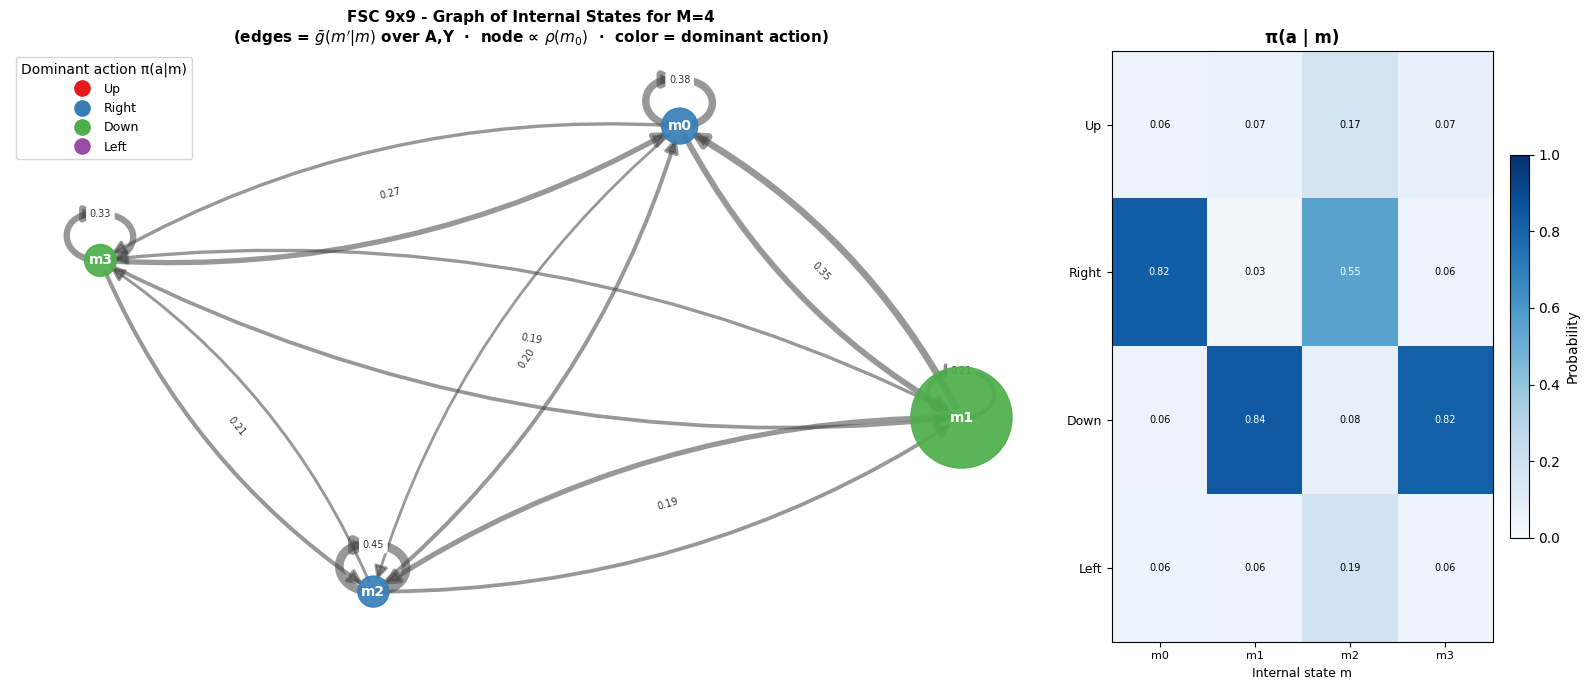

In [59]:
M = 4

fsc_models_by_size = {
    3: load_fsc(f'./models/FSC_3/FSC_{M}states.pt', M=M),
    6: load_fsc(f'./models/FSC_6/FSC_{M}states.pt', M=M),
    9: load_fsc(f'./models/FSC_9/FSC_{M}states.pt', M=M),
}

for size, fsc_loaded in fsc_models_by_size.items():
    plot_fsc_graph(fsc_loaded, size)

In [52]:
def run_fsc_episode(fsc, grid_size, max_steps=100):
    """
    Execute a FSC episode, step by step:
    - the current maze
    - the belief over internal states before the action (with ASCII bars)
    - the chosen action and its probabilities
    - the belief over internal states after the transition
    - the most probable transition (m_prev → m_next with probability)
    Soft execution (belief-based):
    - a_t  = argmax_a  Σ_m  b(m) · π(a|m)
    - b_{t+1}(m') ∝  Σ_m  g(m'|m, a_t, y_t) · b(m)

    Input:
    - fsc: The trained FSC model to run
    - grid_size: Size of the gridworld (used for naming the saved model)
    - max_steps: Maximum steps per episode

    Output:
    - total_reward: Total reward accumulated during the episode
    - step: Number of steps taken in the episode
    - done: Boolean indicating if the goal was reached (True) or if the episode was truncated (False)
    """
    env = POMDPGridworld(size=grid_size, max_steps=max_steps)
    obs, _ = env.reset()

    fsc.eval()
    with torch.no_grad():
        rho = F.softmax(fsc.theta_pi,  dim=0).numpy()  # (M,)
        pie = F.softmax(fsc.theta_pie, dim=0).numpy()  # (A, M)
        g   = F.softmax(fsc.theta_g,   dim=0).numpy()  # (M_next, M_prev, A, Y)

    def print_belief(belief, label):
        print(f"\n  {label}:")
        for m in range(fsc.M):
            bar = '█' * int(belief[m] * 24)
            print(f"    m{m}: {belief[m]:.3f}  {bar}")
        print(f"    → Most probable state: m{int(np.argmax(belief))}")

    belief = rho.copy()
    total_reward = 0.0
    done = False
    truncated = False
    step = 0
    ACTION_NAMES = ['Up', 'Right', 'Down', 'Left']

    while not (done or truncated):
        step += 1
        y_t = obs_to_index(obs)

        # ── Choice of action from the current belief ───────────────────────────
        action_probs = pie @ belief            # P(a) = Σ_m π(a|m)·b(m)  shape (A,)
        action = int(np.argmax(action_probs))

        # ── Print current state ──────────────────────────────────────────────
        print(f"\n{'━'*46}")
        print(f"  STEP {step:3d}  |  obs={obs.tolist()} (y={y_t:>2d})")
        print(f"{'━'*46}")
        env.visualize_grid()
        print_belief(belief, "Belief BEFORE action")
        print(f"\n  Chosen action : [{action}] {ACTION_NAMES[action]}")
        print(f"  Action probabilities : "
            + "  ".join(f"{ACTION_NAMES[a]}={action_probs[a]:.2f}" for a in range(fsc.A)))

        # ── Execute action in the environment ──────────────────────────────
        obs, reward, done, truncated, _ = env.step(action)
        total_reward += reward

        # ── Update belief: b'(m') ∝ Σ_m g(m'|m, a, y) · b(m) ───────────
        g_slice          = g[:, :, action, y_t]       # (M_next, M_prev)
        new_belief_raw   = g_slice @ belief             # (M_next,)
        z                = new_belief_raw.sum()
        new_belief       = new_belief_raw / z if z > 1e-12 else np.ones(fsc.M) / fsc.M

        print_belief(new_belief, "Belief AFTER transition")

        # ── Most probable transition between states ────────────────────────────
        m_prev = int(np.argmax(belief))
        m_next = int(np.argmax(new_belief))
        p_transition = float(g_slice[m_next, m_prev])
        print(f"\n  Dominant transition : m{m_prev} → m{m_next}  "
            f"(g={p_transition:.3f})")
        print(f"  Reward: {reward:+.3f}  |  "
            f"{'GOAL REACHED!' if done else 'Truncated' if truncated else 'Continuing...'}")

        belief = new_belief

    print(f"\n{'━'*46}")
    print(f"  End of episode  |  Step: {step}  |  Total reward: {total_reward:.3f}")
    print(f"  Outcome: {'✓ Success' if done else '✗ Truncated (goal not reached)'}")
    print(f"{'━'*46}\n")

    return total_reward, step, done

In [61]:
# Run FSC episodes on the 6x6 gridworld with the trained FSC model
run_fsc_episode(fsc_models_by_size[6], grid_size=6, max_steps=100)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP   1  |  obs=[1, 1, 0, 1] (y=13)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
AW-W--
---WW-
W-----
W-W-WW
--W---
W---WG

  Belief BEFORE action:
    m0: 0.000  
    m1: 0.931  ██████████████████████
    m2: 0.062  █
    m3: 0.007  
    → Most probable state: m1

  Chosen action : [2] Down
  Action probabilities : Up=0.06  Right=0.06  Down=0.82  Left=0.06

  Belief AFTER transition:
    m0: 0.908  █████████████████████
    m1: 0.077  █
    m2: 0.000  
    m3: 0.015  
    → Most probable state: m0

  Dominant transition : m1 → m0  (g=0.975)
  Reward: -0.010  |  Continuing...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP   2  |  obs=[0, 0, 1, 1] (y= 3)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
-W-W--
A--WW-
W-----
W-W-WW
--W---
W---WG

  Belief BEFORE action:
    m0: 0.908  █████████████████████
    m1: 0.077  █
    m2: 0.000  
    m3: 0.015  
    → Most probable state: m0

  Chosen action : [1] Right
  Action probabili

(0.91, 10, True)

As shown in the output above, at each time step the FSC receives the observation corresponding to the four cardinal directions. Using its current internal belief, it estimates the most likely internal state in which it resides. Based on this state, the controller selects the action with the highest probability according to its learned policy. After executing the action and receiving the new observation, it updates its internal belief to estimate the most likely state at the next time step.

This recursive process allows the FSC to continuously maintain an internal representation of its position within the environment. At every step, the controller keeps track of three pieces of information: its current belief over the internal states, the action that is most appropriate according to that belief, and its updated belief after incorporating the latest observation. By repeatedly updating its belief and selecting actions accordingly, the FSC is able to navigate the maze successfully, reaching the goal in every episode while consistently following the optimal path.

# Part 3: Train BC-LSTM

The final imitation learning approach considered in this work is Behavioral Cloning (BC). Compared to the FSC, there is considerably less theoretical complexity involved. The model consists of a recurrent neural network with an LSTM memory module, trained to imitate the behavior of the expert policy by minimizing the discrepancy between its predicted actions and those demonstrated by the expert.

During training, the network learns to predict the action that the expert would have selected given the current observation and the information stored in its recurrent memory. In this way, the LSTM gradually learns an implicit representation of the environment that enables it to reproduce the expert's behavior as accurately as possible.

The main difference between Behavioral Cloning and the FSC lies in how the internal representation is learned. The FSC explicitly models a finite set of interpretable internal states together with probabilistic transitions between them, whereas Behavioral Cloning relies entirely on the hidden state of the recurrent neural network. As a result, the learned representation is not directly interpretable and behaves as a black box.

Moreover, because Behavioral Cloning is a purely supervised learning approach, its performance depends heavily on the quantity and diversity of the expert demonstrations. The model can only learn from the examples it has observed and does not explicitly infer a generative model of the environment. Consequently, a sufficiently large and representative dataset of expert trajectories is required to achieve good generalization.

To ensure a fair comparison with the FSC, the Behavioral Cloning network was trained using exactly the same expert trajectories collected in the previous experiments. This guarantees that any performance differences between the two approaches can be attributed to the models themselves rather than to differences in the training data.

Although the final Behavioral Cloning architecture appears relatively straightforward, the recurrent neural network required several iterations before reaching its final design. Since the intermediate experiments and architectural revisions are not directly relevant to the objectives of this work, they are omitted for the sake of brevity.

Nevertheless, several improvements were introduced during the development process to increase training stability and generalization performance. An observation encoder was added to learn a richer representation of the environment before feeding the inputs to the recurrent network. Dropout was incorporated to reduce overfitting, while a normalization layer was introduced to improve optimization stability.

In addition, several optimization strategies were evaluated, including different optimizers such as Adam and Stochastic Gradient Descent (SGD), together with various learning-rate scheduling policies. Different learning-rate values were also explored, with 0.0003 consistently providing a good balance between convergence speed and training stability. Finally, an early stopping criterion was adopted to prevent overfitting and terminate training once the validation performance no longer improved.

These modifications resulted in a more stable and reliable training procedure while maintaining a relatively simple overall architecture.

In [53]:
class LSTMPolicy(nn.Module):
    """
    This class implements a simple LSTM-based policy network for Behavioral Cloning.
    It takes as input a sequence of observations and outputs action logits for each time step.
    The architecture consists of:
    - An LSTM layer to process the sequence of observations and capture temporal dependencies.
    - A LayerNorm for stabilizing training.
    - A Dropout layer for regularization.
    - A Linear layer to produce the final action logits.

    Input:
    - obs_dim: Dimension of the input observation (default: 4 for the gridworld)
    - hidden_size: Number of hidden units in the LSTM (default: 32)
    - n_actions: Number of possible actions (default: 4 for the gridworld)
    - num_layers: Number of LSTM layers (default: 1)
    """

    def __init__(self, obs_dim: int = 4, hidden_size: int = 32,
                n_actions: int = 4, num_layers: int = 1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU()
        )

        self.lstm = nn.LSTM(hidden_size, 
                            hidden_size,
                            num_layers=num_layers, 
                            batch_first=True,
                            dropout=0.2 if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(0.2)
        self.head = nn.Linear(hidden_size, n_actions)
        self.layer_norm = nn.LayerNorm(hidden_size)

    def forward(self, obs_seq: torch.Tensor, hidden=None):
        """
        obs_seq : (T, obs_dim)  - sequence of observations in a single episode
        hidden  : None or (h, c) with shape (num_layers, 1, hidden_size)
        Returns : logits (T, n_actions), new hidden state
        """
        x = obs_seq.unsqueeze(0)           # (1, T, obs_dim)
        x = self.encoder(x)                # (1, T, hidden_size)
        out, hidden = self.lstm(x, hidden)  # out: (1, T, H)
        out = self.layer_norm(out)
        out = self.dropout(out)
        logits = self.head(out.squeeze(0))  # (T, n_actions)
        return logits, hidden

    def predict_action(self, obs: np.ndarray, hidden=None, temperature: float = 0.8):
        """
        Predicts the action for a single step at runtime.
        obs    : binary array (4,)
        Returns: integer action, new hidden state
        """
        self.eval()
        with torch.no_grad():
            x = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1,4)
            x = self.encoder(x)  # (1,1,H)
            out, hidden = self.lstm(x, hidden)
            logits = self.head(out.squeeze(0))   # (1, 4)

            # Apply temperature scaling for more stable action selection during evaluation
            probs = F.softmax(logits / temperature, dim=-1)

            # Sample action from the probability distribution
            action = int(torch.multinomial(probs, 1).item())
        return action, hidden

In [54]:
def train_lstm(dataset,
                size: int,
                hidden_size: int = 32,
                num_layers: int = 1,
                max_epochs: int = 500,
                lr: float = 1e-3,
                patience: int = 20,
                batch_size: int = 32,
                temperature: float = 0.8,
                verbose: bool = True,
                ):
    """
    Train LSTM via cross-entropy on expert actions.
    The training is supervised: for each trajectory, the LSTM receives the sequence of observations and must predict the correct action at each step.
    Returns the trained model and the training history (loss curves) of the training and validation sets.

    Input:
    - dataset: A list of trajectories, where each trajectory is a dictionary containing 'observations' (array of shape (T, 4)) and 'actions' (array of shape (T,)).
    - size: Size of the gridworld (used for naming the saved model and plots)
    - hidden_size: Number of hidden units in the LSTM (default: 32)
    - num_layers: Number of LSTM layers (default: 1)
    - max_epochs: Maximum number of training epochs (default: 500)
    - lr: Learning rate for the optimizer (default: 1e-3)
    - patience: Number of epochs to wait for improvement before early stopping (default: 20)
    - batch_size: Number of trajectories per training batch (default: 32)
    - verbose: If True, prints training progress and final loss values
    """

    # Convert dataset: obs float, actions long
    obs_list = [torch.tensor(t['observations'], dtype=torch.float32) for t in dataset]
    act_list = [torch.tensor(t['actions'],      dtype=torch.long)    for t in dataset]
    N = len(obs_list)

    # Split data into train and validation (80% train, 20% val)
    split_idx = int(0.8 * N)
    obs_list_train, obs_list_val = obs_list[:split_idx], obs_list[split_idx:]
    act_list_train, act_list_val = act_list[:split_idx], act_list[split_idx:]

    model     = LSTMPolicy(obs_dim=4, hidden_size=hidden_size,
                            n_actions=4, num_layers=num_layers)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    no_improve      = 0
    history_train         = []
    history_val           = []

    # Early stopping parameters
    best_val_loss = float('inf')

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                                           mode='min', 
                                                           factor=0.5, 
                                                           patience=10)

    if not os.path.exists(f'./models/LSTM_{size}/'):
        os.makedirs(f'./models/LSTM_{size}', exist_ok=True)

    for epoch in range(max_epochs):

        model.train()
        train_running_loss = 0.0

        indices = torch.randperm(split_idx)

        for start in range(0, split_idx, batch_size):
            batch_idx = indices[start: min(start + batch_size, split_idx)]
            optimizer.zero_grad()

            loss_list = [
                F.cross_entropy(
                    model(obs_list_train[int(i)])[0],   # logits (T, 4)
                    act_list_train[int(i)],               # targets (T,)
                    label_smoothing=0.1
                )
                for i in batch_idx
            ]
            loss = torch.stack(loss_list).mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            train_running_loss += loss.item() * len(batch_idx)

        avg_train_loss = train_running_loss / split_idx

        model.eval()
        val_running_loss = 0.0

        with torch.no_grad():
            for start in range(0, N-split_idx, batch_size):
                batch_idx = torch.arange(start, min(start + batch_size, N-split_idx))
                val_loss_list = [
                    F.cross_entropy(
                        model(obs_list_val[int(i)])[0],
                        act_list_val[int(i)]
                    )
                    for i in batch_idx
                ]
                loss = torch.stack(val_loss_list).mean()
                
                val_running_loss += loss.item() * len(batch_idx)

        avg_val_loss = val_running_loss / (N - split_idx)
        history_train.append(avg_train_loss)
        history_val.append(avg_val_loss)

        if verbose and (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:4d} | Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # Early stopping check
        if epoch >= max_epochs*0.2: # Warm-up period
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                no_improve = 0
                torch.save(model.state_dict(), f'./models/LSTM_{size}/best_model.pt')  # Save the best model
            else:
                no_improve += 1
                if no_improve > patience:
                    print("Early stopping triggered")
                    break
        
        scheduler.step(avg_val_loss)

    model.load_state_dict(torch.load(f'./models/LSTM_{size}/best_model.pt'))  # Load the best model
    model.eval()

    if verbose:
        print(f"\nBest Validation Loss: {best_val_loss:.4f}\n")

    return model, (history_train, history_val)

def load_lstm(path, obs_dim: int = 4, hidden_size: int = 32, n_actions: int = 4, num_layers: int = 1):
    '''
    Load a trained LSTM model from disk.

    Input:
    - path: str, path to the saved LSTM model checkpoint
    - obs_dim: int, dimension of the input observations (default: 4)
    - hidden_size: int, number of hidden units in the LSTM (default: 32)
    - n_actions: int, number of possible actions (default: 4)
    - num_layers: int, number of LSTM layers (default: 1)
    
    Output:
    - model: The loaded LSTMPolicy model ready for inference.
    '''

    lstm_loaded = LSTMPolicy(
        obs_dim=obs_dim,
        hidden_size=hidden_size,
        n_actions=n_actions,
        num_layers=num_layers
    )
    lstm_loaded.load_state_dict(torch.load(path, map_location='cpu'), strict=True)
    lstm_loaded.eval()

    return lstm_loaded

### Train

A separate Behavioral Cloning agent was trained for each maze size using architectures with different internal configurations. The number of hidden layers and the size of the hidden representations were scaled according to the complexity of the environment, with larger mazes requiring models with greater representational capacity.

Training was completed in a relatively short amount of time, as all models triggered the early stopping criterion after only a limited number of epochs. This represents one of the practical advantages of the BC-LSTM approach, since the optimization process converges quickly once an appropriate architecture has been selected. However, this benefit comes at the cost of an extensive hyperparameter tuning phase. Considerable effort was required to determine suitable network architectures, optimization settings, and regularization strategies before obtaining the final models.

The training curves exhibit a consistent behavior across all three maze sizes. In every case, the training loss decreases rapidly during the initial epochs, quickly approaching a local minimum. After this initial phase, the loss continues to decrease at a much slower rate until training is terminated by the early stopping criterion.

The validation loss follows the same overall trend, remaining consistently slightly lower than the training loss. This behavior can be attributed primarily to the use of dropout, which is active only during training, making the optimization problem slightly more challenging. Additionally, the stochastic nature of mini-batch optimization introduces a small amount of variability into the training process. Overall, no anomalous behavior was observed, and all three models exhibited stable and consistent convergence throughout training.

In [ ]:
parameters_lstm = [
        (3, "./data/Trajectories_3x3.pkl", 32, 1, 1e-3, 50, 32), # size, path, hidden_size, num_layers, lr, patience, batch_size
        (6, "./data/Trajectories_6x6.pkl", 64, 2, 1e-3, 50, 32),
        (9, "./data/Trajectories_9x9.pkl", 128, 2, 1e-3, 50, 32)
    ]

all_lstm = [] # Save all LSTM models
all_histories = [] # Save all training histories for each LSTM

for size, path, hidden_size, num_layers, lr, patience, batch_size in parameters_lstm:
    with open(path, 'rb') as f:
        dataset = pickle.load(f)
    model, (history_train, history_val) = train_lstm(dataset,
                                                        size=size,
                                                        hidden_size=hidden_size,
                                                        num_layers=num_layers,
                                                        max_epochs=500,
                                                        lr=lr,
                                                        patience=patience,
                                                        batch_size=batch_size,
                                                        verbose=True)

    all_lstm.append(model)
    all_histories.append((history_train, history_val))

    plot_lstm_training_history(size, history_train, history_val)

Epoch   50 | Loss: 0.7711 | Val Loss: 0.5907
Epoch  100 | Loss: 0.7664 | Val Loss: 0.5907
Epoch  150 | Loss: 0.7714 | Val Loss: 0.5906
Early stopping triggered

Best Validation Loss: 0.5906

Epoch   50 | Loss: 0.7855 | Val Loss: 0.6604
Epoch  100 | Loss: 0.7822 | Val Loss: 0.6579
Epoch  150 | Loss: 0.7828 | Val Loss: 0.6581
Early stopping triggered

Best Validation Loss: 0.6580

Epoch   50 | Loss: 0.8010 | Val Loss: 0.6864
Epoch  100 | Loss: 0.7969 | Val Loss: 0.6827
Epoch  150 | Loss: 0.7968 | Val Loss: 0.6824
Early stopping triggered

Best Validation Loss: 0.6821



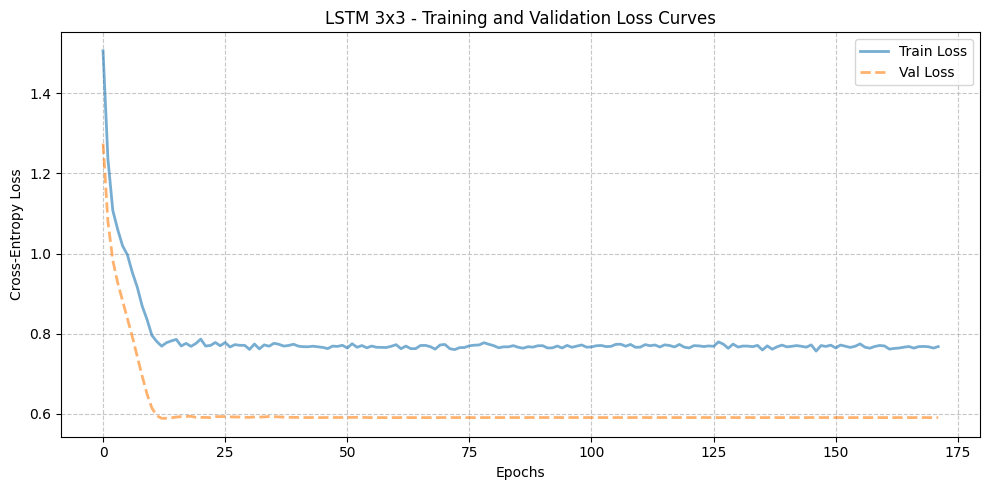

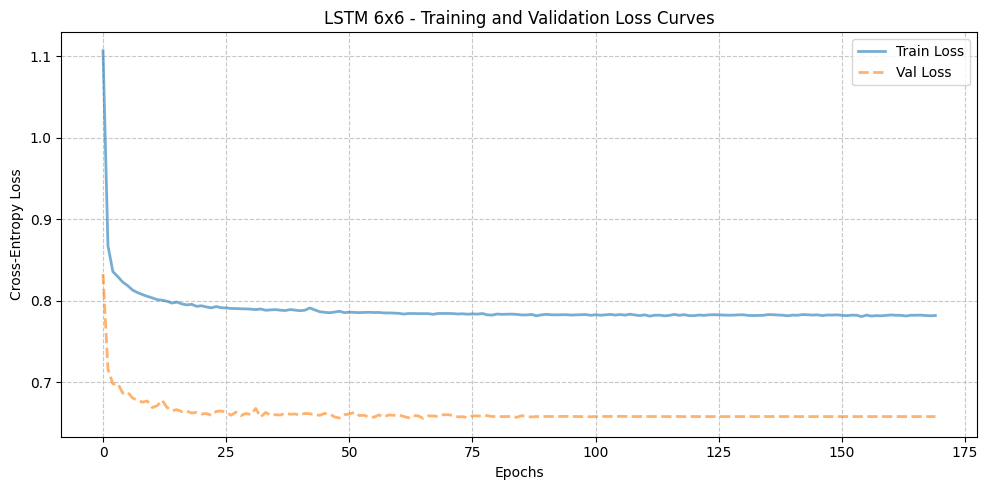

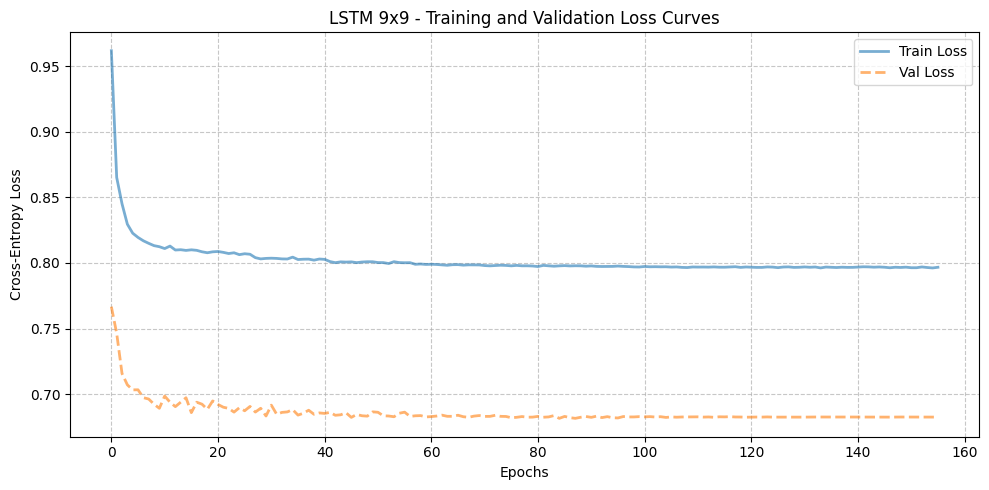

In [76]:
plot_lstm_training_history(3, all_histories[0][0], all_histories[0][1])
plot_lstm_training_history(6, all_histories[1][0], all_histories[1][1])
plot_lstm_training_history(9, all_histories[2][0], all_histories[2][1])

# Part 4: FSC vs BC-LSTM


## Experimental Evaluation

The final stage of this work consists of comparing the two imitation learning approaches—**Finite State Controllers (FSCs)** and **Behavioral Cloning with LSTM (BC-LSTM)**—across multiple evaluation criteria. The analysis is designed not only to assess their ability to imitate the expert policy, but also to compare their efficiency, scalability, robustness, and interpretability. Each of these aspects highlights a different strength or limitation of the proposed approaches.

### Qualitative Evaluation

Before presenting the quantitative analysis, a qualitative comparison is provided through a set of animated GIFs showing the behavior of the three agents across the three maze sizes. Each animation illustrates the complete navigation process from the initial state to the goal, allowing the reader to observe how the different policies interact with the environment.

These visualizations complement the numerical results by providing an intuitive understanding of the agents' behavior. In particular, they make it easier to assess whether the learned policies follow the optimal path, how efficiently they reach the goal, and under which circumstances they deviate from the expert behavior or become trapped in suboptimal trajectories.

Although qualitative evaluations cannot replace quantitative metrics, they offer valuable insight into the strengths and weaknesses of each approach, making the subsequent analysis easier to interpret.


### Policy Accuracy

The primary objective is to verify whether both models successfully reproduce the behavior of the expert PPO policy. To this end, three complementary performance metrics are considered.

The first metric is the **Success Rate**, defined as the percentage of evaluation episodes in which the agent successfully reaches the goal. Each model is evaluated over 100 independent episodes for every maze size.

The second metric is the **average trajectory length**. Whenever an episode is successfully completed, the number of steps required to reach the goal is recorded. Comparing this value with the expert policy allows us to determine whether the learned controllers recover the same optimal trajectories or produce longer, less efficient paths.

Finally, the **average cumulative reward** is measured. Since the environment rewards reaching the goal while penalizing unnecessary movements, this metric captures both the success and the efficiency of the learned policies. The cumulative rewards of the expert PPO policy, the FSC, and the BC-LSTM are directly compared.

These results are summarized using grouped bar charts, where each maze size (3×3, 6×6, and 9×9) is associated with three bars representing the performance of the expert policy, the FSC, and the BC-LSTM.

---

### Parameter Efficiency

One of the main motivations behind the FSC framework is its ability to represent complex behaviors using a remarkably small number of parameters. Consequently, model efficiency is evaluated by comparing the number of trainable parameters required by each approach.

For the FSC, the total number of parameters is given by

$$
M\left(1 + A + M A Y\right),
$$

where (M) denotes the number of internal memory states, (A) the number of actions, and (Y) the number of observations.

The BC-LSTM contains considerably more trainable parameters due to the recurrent network, hidden layers, and observation encoder.

A comparative table is reported for each maze size, showing the parameter count of both models. In addition, a simple efficiency indicator, defined as the **Success Rate per trainable parameter**, is introduced to quantify how effectively each parameter contributes to the overall performance. Although this metric is not standard in the literature, it provides an intuitive measure of model compactness.

---

### Computational Scalability

The computational requirements of the two approaches are analyzed as the maze size increases.

The first quantity considered is the **training time**, measured as the time required for each model to converge according to its respective stopping criterion. Since the FSC is optimized through likelihood maximization while the BC-LSTM relies on supervised learning with early stopping, comparing these values provides insight into the computational cost associated with each approach.

The second metric is the **inference time**, namely the average time required to select a single action during execution. Owing to its simple probabilistic structure and limited number of parameters, the FSC is expected to require significantly less computation than the recurrent neural network.

---

### Robustness to Distribution Shift

Behavioral Cloning methods are well known to suffer from **covariate shift**: small deviations from the expert trajectories may accumulate over time, leading the policy into regions of the state space that were never observed during training.

To evaluate this phenomenon, the trained agents are tested in a modified environment where action execution is perturbed with a fixed probability. Specifically, with probability (\varepsilon), the intended action is replaced by a random alternative. This stochastic perturbation forces the agents to recover from unexpected situations that differ from the expert demonstrations.

Performance is again measured through Success Rate and trajectory length. 

Because stochastic trajectories were intentionally included during dataset collection, the FSC is expected to exhibit greater robustness under these perturbations.

---

### Interpretability

The final and perhaps most distinctive aspect of the evaluation concerns **interpretability**.

Unlike neural network policies, whose internal representations are distributed across thousands of parameters, an FSC provides an explicit probabilistic model of its decision-making process. The learned controller can therefore be visualized directly as a finite-state graph, where each node represents an internal memory state and each edge corresponds to a learned probabilistic transition.

No comparable interpretation can be extracted from the hidden activations of the BC-LSTM, whose decision process remains largely opaque. This distinction highlights one of the principal advantages of FSCs over conventional neural network policies. Beyond improving model transparency, interpretability is particularly important in safety-critical domains—such as healthcare, autonomous systems, and industrial control—where understanding and verifying an agent's decisions is often as important as achieving high predictive performance.

This last part is already been analysed after the FSC training. So, I'm not gonna go over it again.


### Plot functions

This section contains all the function that plot the required metrics.

In [ ]:
def make_trajectories_grid_gif(
    trajectories,
    gif_path="./plots/trajectories_grid.gif",
    model_order=None,
    size_order=None,
    fps=6,
    cell_scale=3.2,
    wall_map=None
):
    """
    Create a GIF visualizing trajectories of different models and grid sizes in a 3x3 grid format.
    Each cell of the grid corresponds to a specific model (FSC, LSTM, RPPO) and grid size (3x3, 6x6, 9x9).

    Inputs:
    - trajectories: List of 9 trajectory dictionaries, each containing:
        - "model": string, one of "FSC", "LSTM", "RPPO"
        - "size": int, one of 3, 6, 9
        - "positions": list of (x, y) tuples representing the agent's path
        - "goal": optional (x, y) tuple for the goal position (if not provided, defaults to bottom-right corner)
    - gif_path: string, output path for the generated GIF
    - model_order: optional list of model names in the order they should appear in columns (default: sorted order)
    - size_order: optional list of grid sizes in the order they should appear in rows (default: sorted order)
    - fps: frames per second for the GIF
    - cell_scale: scaling factor for the size of each cell in inches (default: 3.2)
    - wall_map: optional dict mapping size to 2D list of 0/1 for free/wall cells (if not provided, uses a default pattern)
    """

    if len(trajectories) != 9:
        raise ValueError(f"Expected exactly 9 trajectories (3 models x 3 sizes), but got {len(trajectories)}.")

    # If model_order or size_order are not provided, infer them from the trajectories
    if model_order is None:
        model_order = sorted(list({t["model"] for t in trajectories}))
    if size_order is None:
        size_order = sorted(list({int(t["size"]) for t in trajectories}))

    if len(model_order) != 3 or len(size_order) != 3:
        raise ValueError("Expected exactly 3 models and 3 sizes.")
    
    # Index trajectories for quick lookup
    lookup = {}
    for t in trajectories:
        key = (int(t["size"]), t["model"])
        if key in lookup:
            raise ValueError(f"Found duplicate trajectories for {key}.")
        if "positions" not in t or len(t["positions"]) == 0:
            raise ValueError(f"Empty or missing positions for {key}.")
        lookup[key] = t

    # Verify complete 3x3 coverage
    for s in size_order:
        for m in model_order:
            if (s, m) not in lookup:
                raise ValueError(f"Missing trajectory for size={s}, model={m}.")

    # GIF duration: maximum number of steps across all trajectories
    max_len = max(len(t["positions"]) for t in trajectories)

    fig, axes = plt.subplots(
        nrows=3, ncols=3, figsize=(cell_scale * 3.2, cell_scale * 3.2), dpi=120
    )

    # Color map: free, wall, goal
    cmap = ListedColormap(["#f7f7f7", "#1f2937", "#22c55e"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

    frames = []

    for frame_idx in range(max_len):
        for r, size in enumerate(size_order):
            for c, model_name in enumerate(model_order):
                ax = axes[r, c]
                ax.clear()

                tr = lookup[(size, model_name)]
                pos = tr["positions"]
                goal = tr.get("goal", (size - 1, size - 1))

                # Freeze frame if trajectory is shorter than max_len
                idx = min(frame_idx, len(pos) - 1)
                cur_x, cur_y = pos[idx]

                # Base grid: 0 free, 1 wall, 2 goal
                if wall_map is None:
                    # Use GRID_WORD already present in the notebook
                    base = np.array(GRID_WORD[:size, :size], dtype=int)
                else:
                    base = np.array(wall_map[size], dtype=int).copy()

                gx, gy = goal
                if 0 <= gx < size and 0 <= gy < size:
                    base[gy, gx] = 2

                ax.imshow(base, cmap=cmap, norm=norm, origin="upper")

                # Path up to the current frame
                path_xy = np.array(pos[: idx + 1], dtype=float)
                if len(path_xy) > 1:
                    ax.plot(
                        path_xy[:, 0], path_xy[:, 1],
                        color="#2563eb", linewidth=2.0, alpha=0.9
                    )

                # Current agent
                ax.scatter(
                    [cur_x], [cur_y],
                    s=70, c="#ef4444", edgecolors="white", linewidths=0.8, zorder=3
                )

                # If finished early, show "freeze" flag
                if frame_idx >= len(pos) - 1:
                    ax.text(
                        0.98, 0.04, "freeze",
                        transform=ax.transAxes,
                        ha="right", va="bottom",
                        fontsize=8, color="#111827",
                        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1.5)
                    )

                # Ticks and limits
                ax.set_xlim(-0.5, size - 0.5)
                ax.set_ylim(size - 0.5, -0.5)
                ax.set_aspect("equal")
                ax.set_xticks([])
                ax.set_yticks([])

                # Titles
                ax.set_title(f"{model_name} | {size}x{size}", fontsize=9)
        fig.suptitle(f"Step {frame_idx + 1}/{max_len}", fontsize=12)
        fig.tight_layout()

        # Render frame RGB (backend-agnostic)
        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=fig.dpi)
        buf.seek(0)
        rgb = imageio.imread(buf)[:, :, :3].copy()
        buf.close()
        frames.append(rgb)

    plt.show(fig)
    plt.close(fig)

    imageio.mimsave(gif_path, frames, fps=fps)
    print(f"GIF saved in: {gif_path}\n")

def _to_xy_tuple(agent_pos):
    # agent_pos in your env is [x, y]
    return (int(agent_pos[0]), int(agent_pos[1]))


def collect_single_fsc_trajectory(fsc_model, grid_size, max_steps):
    """
        Collects a single trajectory from the FSC model interacting with the POMDPGridworld environment.

        Inputs:
        - fsc_model: an instance of the FSC model with parameters theta_pi, theta_p
        - grid_size: int, size of the gridworld (3, 6, or 9)
        - max_steps: int, maximum number of steps to run the episode

        Output:
        - A dictionary containing:
            - "size": int, the grid size
            - "positions": list of (x, y) tuples representing the agent's path
            - "actions": list of int, the actions taken at each step
            - "rewards": list of float, the rewards received at each step
            - "done": bool, whether the episode ended by reaching the goal
            - "truncated": bool, whether the episode ended by reaching max_steps
            - "length": int, the number of steps taken
            - "goal": (x, y) tuple for the goal position
    """
    env = POMDPGridworld(size=grid_size, max_steps=max_steps)
    obs, _ = env.reset()

    fsc_model.eval()
    with torch.no_grad():
        rho = F.softmax(fsc_model.theta_pi, dim=0).cpu().numpy()    # (M,)
        pie = F.softmax(fsc_model.theta_pie, dim=0).cpu().numpy()   # (A, M)
        g = F.softmax(fsc_model.theta_g, dim=0).cpu().numpy()       # (M_next, M_prev, A, Y)

    belief = rho.copy()

    positions = [_to_xy_tuple(env.agent_pos)]
    actions = []
    rewards = []

    done = False
    truncated = False

    while not (done or truncated):
        y_t = obs_to_index(obs)

        # FSC action selection: argmax_a sum_m pi(a|m) * b(m)
        action_probs = pie @ belief
        action = int(np.argmax(action_probs))

        obs, reward, done, truncated, _ = env.step(action)

        actions.append(action)
        rewards.append(float(reward))
        positions.append(_to_xy_tuple(env.agent_pos))

        # Belief update: b'(m') prop sum_m g(m'|m,a,y) * b(m)
        g_slice = g[:, :, action, y_t]  # (M_next, M_prev)
        new_belief_raw = g_slice @ belief
        z = new_belief_raw.sum()
        if z > 1e-12:
            belief = new_belief_raw / z
        else:
            belief = np.ones_like(belief) / len(belief)

    return {
        "size": int(grid_size),
        "positions": positions,
        "actions": actions,
        "rewards": rewards,
        "done": bool(done),
        "truncated": bool(truncated),
        "length": len(actions),
        "goal": (int(grid_size - 1), int(grid_size - 1)),
    }


def collect_single_recurrent_trajectory(model, grid_size, max_steps, kind):
    """
    Collects a single trajectory from a recurrent model (either LSTM or RecurrentPPO) interacting with the POMDPGridworld environment.

    Inputs:
    - model: an instance of the recurrent model (LSTM or RecurrentPPO)
    - grid_size: int, size of the gridworld (3, 6, or 9)
    - max_steps: int, maximum number of steps to run the episode
    - kind: string, either "lstm" or "rppo" to specify the type of model (used for action prediction)

    Output:
    - A dictionary containing:
        - "size": int, the grid size
        - "positions": list of (x, y) tuples representing the agent's path
        - "actions": list of int, the actions taken at each step
        - "rewards": list of float, the rewards received at each step
        - "done": bool, whether the episode ended by reaching the goal
        - "truncated": bool, whether the episode ended by reaching max_steps
        - "length": int, the number of steps taken
        - "goal": (x, y) tuple for the goal position
    """
    env = POMDPGridworld(size=grid_size, max_steps=max_steps)
    obs, _ = env.reset()

    positions = [_to_xy_tuple(env.agent_pos)]
    actions = []
    rewards = []

    done = False
    truncated = False

    kind = kind.lower()

    if kind == "rppo":
        lstm_states = None
        episode_starts = np.ones((1,), dtype=bool)

        while not (done or truncated):
            action, lstm_states = model.predict(
                obs,
                state=lstm_states,
                episode_start=episode_starts,
                deterministic=True
            )
            action = int(action)

            obs, reward, done, truncated, _ = env.step(action)
            episode_starts = np.zeros((1,), dtype=bool)

            actions.append(action)
            rewards.append(float(reward))
            positions.append(_to_xy_tuple(env.agent_pos))

    elif kind == "lstm":
        model.eval()
        hidden = None

        while not (done or truncated):
            action, hidden = model.predict_action(obs, hidden=hidden)
            action = int(action)

            obs, reward, done, truncated, _ = env.step(action)

            actions.append(action)
            rewards.append(float(reward))
            positions.append(_to_xy_tuple(env.agent_pos))
    else:
        raise ValueError("kind must be 'rppo' or 'lstm'.")

    return {
        "size": int(grid_size),
        "positions": positions,
        "actions": actions,
        "rewards": rewards,
        "done": bool(done),
        "truncated": bool(truncated),
        "length": len(actions),
        "goal": (int(grid_size - 1), int(grid_size - 1)),
    }


def _get_model_for_size(model_map, size):
    """
    Supports both integer keys (3,6,9) and string keys ('3x3','6x6','9x9').
    """
    if size in model_map:
        return model_map[size]

    key_str = f"{size}x{size}"
    if key_str in model_map:
        return model_map[key_str]

    raise KeyError(f"Model missing for size={size} (tried keys: {size}, '{key_str}').")


def collect_9_trajectories_for_grid_gif(
    fsc_models_by_size,
    lstm_models_by_size,
    rppo_models_by_size,
    sizes=(3, 6, 9),
    max_steps_by_size=None,
    model_order=("FSC", "LSTM", "RPPO"),
):
    """
    Returns a list of 9 trajectories in the format suitable for make_trajectories_grid_gif:
    columns = model_order, rows = sizes.
    """
    if len(sizes) != 3:
        raise ValueError("sizes must contain exactly 3 dimensions.")
    if len(model_order) != 3:
        raise ValueError("model_order must contain exactly 3 models.")

    if max_steps_by_size is None:
        # defaults consistent with your notebook
        max_steps_by_size = {3: 100, 6: 500, 9: 1000}

    output = []

    for size in sizes:
        max_steps = int(max_steps_by_size[size])

        for model_name in model_order:
            if model_name == "FSC":
                model = _get_model_for_size(fsc_models_by_size, size)
                traj = collect_single_fsc_trajectory(model, size, max_steps)

            elif model_name == "LSTM":
                model = _get_model_for_size(lstm_models_by_size, size)
                traj = collect_single_recurrent_trajectory(model, size, max_steps, kind="lstm")

            elif model_name == "RPPO":
                model = _get_model_for_size(rppo_models_by_size, size)
                traj = collect_single_recurrent_trajectory(model, size, max_steps, kind="rppo")

            else:
                raise ValueError(f"Unsupported model name: {model_name}")

            traj["model"] = model_name
            output.append(traj)

    return output

def plot_model_comparison_bars(
    results_rppo,
    results_fsc,
    results_lstm,
    sizes=(3, 6, 9),
    save_dir="./plots/Comparison",
):
    """
    Plot a grouped bar chart comparing RPPO, FSC, and LSTM across different grid sizes for:
    - Success Rate (%)
    - Average Reward
    - Average Steps

    Inputs:
    - results_rppo: Dictionary with RPPO results for each size (keys: size, values: dict with 'success_rate', 'average_reward', 'average_steps')
    - results_fsc: Dictionary with FSC results for each size (same structure as results_rppo)
    - results_lstm: Dictionary with LSTM results for each size (same structure as results_rppo)
    - sizes: Tuple of grid sizes to include in the plot (default: (3, 6, 9))
    - save_dir: Directory to save the resulting plot (default: "./plots/Comparison")

    Outputs:
    - A saved PNG file with the comparison bar chart in the specified directory.
    """

    def _get_entry(results, size):
        for key in (size, str(size), f"{size}x{size}"):
            if key in results:
                return results[key]
        raise KeyError(f"Missing results for size={size}. Available keys: {list(results.keys())}")

    metrics = [
        ("success_rate", "Success rate (%)", "Success Rate"),
        ("average_reward", "Average reward", "Average Reward"),
        ("average_steps", "Average steps", "Average Steps"),
    ]

    model_specs = [
        ("RPPO", results_rppo, "#056875"), 
        ("FSC", results_fsc, "#50C2E5"),
        ("LSTM", results_lstm, "#C9495E"),
    ]

    target_reward = {
    3: 0.97,
    6: 0.91,
    9: 0.85,
    }

    target_steps = {
        3: 4,
        6: 10,
        9: 16,
    }

    target_success = {
        3: 100,
        6: 100,
        9: 100,
    }

    x = np.arange(len(sizes))
    
    width = 0.20 

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    for ax, (metric_key, ylabel, title) in zip(axes, metrics):
        for offset, (model_name, results, color) in zip(
            (-width, 0.0, width),
            model_specs
        ):
            values = [float(_get_entry(results, size)[metric_key]) for size in sizes]
            bars = ax.bar(
                x + offset,
                values,
                width=width,
                color=color,
                alpha=0.9,
                label=model_name,
                edgecolor="white", 
                linewidth=0.5
            )

            for bar in bars:
                height = bar.get_height()
                ax.annotate(
                    f"{height:.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

            if metric_key == "average_reward":
                targets = [target_reward[s] for s in sizes]
                ax.plot(
                    x,
                    targets,
                    color="red",
                    linestyle="--",
                    linewidth=2,
                    marker="o",
                    markersize=5,
                )

            elif metric_key == "average_steps":
                targets = [target_steps[s] for s in sizes]
                ax.plot(
                    x,
                    targets,
                    color="red",
                    linestyle="--",
                    linewidth=2,
                    marker="o",
                    markersize=5,
                )

            elif metric_key == "success_rate":
                targets = [target_success[s] for s in sizes]
                ax.plot(
                    x,
                    targets,
                    color="red",
                    linestyle="--",
                    linewidth=2,
                    marker="o",
                    markersize=5,
                )

        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_ylabel(ylabel)
        ax.set_xticks(x)
        ax.set_xticklabels([str(size) for size in sizes])
        ax.grid(True, axis="y", linestyle="--", alpha=0.4)
        
        ax.margins(y=0.15) 
        
        if metric_key == "success_rate":
            ax.set_ylim(0, 115)

    axes[0].legend(loc="best")

    plt.suptitle("RPPO vs FSC vs LSTM across grid sizes", fontsize=14, fontweight="bold")
    plt.tight_layout(rect=(0, 0.02, 1, 0.95))

    if not os.path.exists(save_dir):
        os.makedirs(save_dir, exist_ok=True)

    output_path = os.path.join(save_dir, "model_comparison_success_reward_steps.png")
    if os.path.exists(output_path):
        os.remove(output_path)

    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved comparison plot to: {output_path}")

def plot_inference_time_comparison(
    times_fsc,
    times_lstm,
    sizes=(3, 6, 9),
    save_dir="./plots/Comparison",
):
    """
    Plot a line graph comparing inference times of FSC and LSTM across different grid sizes.

    Inputs:
    - times_fsc: Dictionary with FSC inference times for each size (keys: size, values: time in seconds)
    - times_lstm: Dictionary with LSTM inference times for each size (same structure as times_fsc)
    - sizes: Tuple of grid sizes to include in the plot (default: (3, 6, 9))
    - save_dir: Directory to save the resulting plot (default: "./plots/Comparison")

    Outputs:
    - A saved PNG file with the inference time comparison line graph in the specified directory.
    """

    def _get_entry(results, size):
        for key in (size, str(size), f"{size}x{size}"):
            if key in results:
                return results[key]
        raise KeyError(f"Missing results for size={size}. Available keys: {list(results.keys())}")

    fsc_values = [float(_get_entry(times_fsc, size)) for size in sizes]
    lstm_values = [float(_get_entry(times_lstm, size)) for size in sizes]
    
    x_labels = [f"{size}x{size}" for size in sizes]
    
    color_fsc = "#50C2E5"
    color_lstm = "#C9495E"

    plt.figure(figsize=(8, 6))
    
    plt.plot(x_labels, fsc_values, marker='o', markersize=8, color=color_fsc, linewidth=2.5, label='FSC')
    plt.plot(x_labels, lstm_values, marker='s', markersize=8, color=color_lstm, linewidth=2.5, label='LSTM')
    
    plt.title("Inference Time per Action across Grid Sizes", fontsize=14, fontweight="bold")
    plt.xlabel("Maze Size", fontsize=12)
    plt.ylabel("Time (seconds)", fontsize=12)
    
    plt.yscale('log')
    
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    
    plt.legend(loc="best", fontsize=11)
    
    plt.tight_layout()

    if not os.path.exists(save_dir):
        os.makedirs(save_dir, exist_ok=True)

    output_path = os.path.join(save_dir, "inference_time_comparison.png")
    if os.path.exists(output_path):
        os.remove(output_path)

    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved inference time plot to: {output_path}")

def plot_robustness_bars(
    results_fsc,
    results_lstm,
    randomness,
    sizes=(3, 6, 9),
    save_dir="./plots/Comparison",
    ):
    """
    Plot a grouped bar chart comparing FSC and LSTM across different grid sizes for:
    - Success Rate (%)
    - Average Reward
    - Average Steps

    Inputs:
    - results_fsc: Dictionary with FSC results for each size (keys: size, values: dict with 'success_rate', 'average_reward', 'average_steps')
    - results_lstm: Dictionary with LSTM results for each size (same structure as results_fsc)
    - sizes: Tuple of grid sizes to include in the plot (default: (3, 6, 9))
    - save_dir: Directory to save the resulting plot (default: "./plots/Comparison")

    Outputs:
    - A saved PNG file with the comparison bar chart in the specified directory.
    """

    def _get_entry(results, size):
        for key in (size, str(size), f"{size}x{size}"):
            if key in results:
                return results[key]
        raise KeyError(f"Missing results for size={size}. Available keys: {list(results.keys())}")

    metrics = [
        ("success_rate", "Success rate (%)", "Success Rate"),
        ("average_reward", "Average reward", "Average Reward"),
        ("average_steps", "Average steps", "Average Steps"),
    ]

    model_specs = [
        ("FSC", results_fsc, "#50C2E5"),
        ("LSTM", results_lstm, "#C9495E"),
    ]

    target_reward = {
        3: 0.97,
        6: 0.91,
        9: 0.85,
    }

    target_steps = {
        3: 4,
        6: 10,
        9: 16,
    }

    target_success = {
        3: 100,
        6: 100,
        9: 100,
    }

    x = np.arange(len(sizes))
    
    width = 0.20 

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    for ax, (metric_key, ylabel, title) in zip(axes, metrics):
        for offset, (model_name, results, color) in zip(
            (-width, 0.0, width),
            model_specs
        ):
            values = [float(_get_entry(results, size)[metric_key]) for size in sizes]
            bars = ax.bar(
                x + offset,
                values,
                width=width,
                color=color,
                alpha=0.9,
                label=model_name,
                edgecolor="white", 
                linewidth=0.5
            )

            for bar in bars:
                height = bar.get_height()
                ax.annotate(
                    f"{height:.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

            if metric_key == "average_reward":
                targets = [target_reward[s] for s in sizes]
                ax.plot(
                    x,
                    targets,
                    color="red",
                    linestyle="--",
                    linewidth=2,
                    marker="o",
                    markersize=5,
                    label="Target"
                )

            elif metric_key == "average_steps":
                targets = [target_steps[s] for s in sizes]
                ax.plot(
                    x,
                    targets,
                    color="red",
                    linestyle="--",
                    linewidth=2,
                    marker="o",
                    markersize=5,
                    label="Target"
                )

            elif metric_key == "success_rate":
                targets = [target_success[s] for s in sizes]
                ax.plot(
                    x,
                    targets,
                    color="red",
                    linestyle="--",
                    linewidth=2,
                    marker="o",
                    markersize=5,
                    label="Target"
                )

        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_ylabel(ylabel)
        ax.set_xticks(x)
        ax.set_xticklabels([str(size) for size in sizes])
        ax.grid(True, axis="y", linestyle="--", alpha=0.4)
        
        ax.margins(y=0.15) 
        
        if metric_key == "success_rate":
            ax.set_ylim(0, 115)

    axes[0].legend(loc="best")

    plt.suptitle(f"FSC vs LSTM Robustness across grid sizes (Randomness: {randomness})", fontsize=14, fontweight="bold")
    plt.tight_layout(rect=(0, 0.02, 1, 0.95))

    if not os.path.exists(save_dir):
        os.makedirs(save_dir, exist_ok=True)

    output_path = os.path.join(save_dir, f"model_robustness_randomness_{randomness}.png")
    if os.path.exists(output_path):
        os.remove(output_path)

    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved comparison plot to: {output_path}")


## Qualitative Evaluation

The animations already provide a clear indication of the trends that will be confirmed by the quantitative analysis, even before examining any numerical metrics. Both Recurrent PPO and the Finite State Controller (FSC) consistently follow the optimal path, reaching the goal using the minimum possible number of steps in all three maze sizes.

In contrast, the Behavioral Cloning LSTM exhibits a noticeable degradation in performance as the complexity of the environment increases. While it successfully solves the 3×3 maze, it fails to consistently follow the optimal trajectory in the 6×6 and 9×9 environments. In the largest maze, the learned policy even converges to a markedly suboptimal route, requiring approximately 60 steps to reach the goal.

A plausible explanation for this behavior is the increasing length of the trajectories. As the temporal horizon grows, the LSTM must preserve relevant information over a larger number of time steps, making it more difficult to accurately maintain the internal representation required for optimal decision-making. Consequently, small prediction errors can accumulate throughout the episode, eventually causing the policy to deviate from the expert trajectory and follow a longer, less efficient path.

In [63]:
######################################################################
#                           Make the GIF                             # 
######################################################################

# Load FSC models with M = 4, which is the overall best M value for all sizes.
M = 4
fsc_models_by_size = {
    3: load_fsc(f'./models/FSC_3/FSC_{M}states.pt', M=M),
    6: load_fsc(f'./models/FSC_6/FSC_{M}states.pt', M=M),
    9: load_fsc(f'./models/FSC_9/FSC_{M}states.pt', M=M),
}

# Load the best LSTM models saved with the validation loss during training.
lstm_models_by_size = {
    3: load_lstm('./models/LSTM_3/best_model.pt', obs_dim=4, hidden_size=32, n_actions=4, num_layers=1),
    6: load_lstm('./models/LSTM_6/best_model.pt', obs_dim=4, hidden_size=64, n_actions=4, num_layers=2),
    9: load_lstm('./models/LSTM_9/best_model.pt', obs_dim=4, hidden_size=128, n_actions=4, num_layers=2),
}

# Load the best Recurrent PPO models saved during training.
rppo_models_by_size = {
    3: load_rppo("models/RecurrentPPO_3_100_0.0003/best_model"),
    6: load_rppo("models/RecurrentPPO_6_500_0.0003/best_model"),
    9: load_rppo("models/RecurrentPPO_9_1000_0.0005/best_model"),
}

trajectories_9 = collect_9_trajectories_for_grid_gif(
    fsc_models_by_size=fsc_models_by_size,
    lstm_models_by_size=lstm_models_by_size,
    rppo_models_by_size=rppo_models_by_size,
    sizes=(3, 6, 9),
    max_steps_by_size={3: 100, 6: 100, 9: 100},
    model_order=("FSC", "LSTM", "RPPO"),
)

make_trajectories_grid_gif(
    trajectories_9,
    gif_path="./plots/Comparison/Simulation_grid.gif",
    model_order=["FSC", "LSTM", "RPPO"],
    size_order=[3, 6, 9],
    fps=6
)

GIF saved in: ./plots/Comparison/Simulation_grid.gif



## Policy Accuracy

In [57]:
def run_rppo_episode(rppo, grid_size, max_steps=100):
    """
    Run a single episode in the POMDPGridworld environment using the provided RPPO model to select actions.

    Inputs:
    - rppo: An instance of the RPPO model
    - grid_size: Size of the gridworld (e.g., 3, 6, 9)
    - max_steps: Maximum number of steps to run in the episode (default: 100)

    Outputs:
    - total_reward: Total reward accumulated during the episode
    - steps: Number of steps taken in the episode
    - success: Boolean indicating whether the episode ended in success (reaching the goal)
    """
    env = POMDPGridworld(size=grid_size, max_steps=max_steps)
    obs, _ = env.reset()

    lstm_states = None
    episode_starts = np.ones((1,), dtype=bool) 

    total_reward = 0.0
    done = False
    truncated = False
    step = 0

    while not (done or truncated):
        step += 1

        action, lstm_states = rppo.predict(obs, state=lstm_states, episode_start=episode_starts, deterministic=True)

        obs, reward, done, truncated, _ = env.step(action)
        episode_starts = np.zeros((1,), dtype=bool) # Immediately after the first action, set to False
        total_reward += reward

    return total_reward, step, done

def run_fsc_episode(fsc, grid_size, max_steps=100, verbose=False):
    """
    Run a complete episode with the loaded FSC and print, step by step:
    - the current maze
    - the belief over internal states before the action (with ASCII bars)
    - the chosen action and its probabilities
    - the belief over internal states after the transition
    - the most probable transition (m_prev → m_next with probability)
    Soft execution (belief-based):
    - a_t  = argmax_a  Σ_m  b(m) · π(a|m)
    - b_{t+1}(m') ∝  Σ_m  g(m'|m, a_t, y_t) · b(m)

    Inputs:
    - fsc: An instance of the FSC model
    - grid_size: Size of the gridworld (e.g., 3, 6, 9)
    - max_steps: Maximum number of steps to run in the episode (default: 100)
    - verbose: If True, prints detailed step-by-step information (default: False)

    Outputs:
    - total_reward: Total reward accumulated during the episode
    - steps: Number of steps taken in the episode
    - success: Boolean indicating whether the episode ended in success (reaching the goal)
    """
    env = POMDPGridworld(size=grid_size, max_steps=max_steps)
    obs, _ = env.reset()

    fsc.eval()
    with torch.no_grad():
        rho = F.softmax(fsc.theta_pi,  dim=0).numpy()  # (M,)
        pie = F.softmax(fsc.theta_pie, dim=0).numpy()  # (A, M)
        g   = F.softmax(fsc.theta_g,   dim=0).numpy()  # (M_next, M_prev, A, Y)

    def print_belief(belief, label):
        print(f"\n  {label}:")
        for m in range(fsc.M):
            bar = '█' * int(belief[m] * 24)
            print(f"    m{m}: {belief[m]:.3f}  {bar}")
        print(f"    → Most probable state: m{int(np.argmax(belief))}")

    belief = rho.copy()
    total_reward = 0.0
    done = False
    truncated = False
    step = 0
    ACTION_NAMES = ['Up', 'Right', 'Down', 'Left']

    while not (done or truncated):
        step += 1
        y_t = obs_to_index(obs)

        action_probs = pie @ belief            # P(a) = Σ_m π(a|m)·b(m)  shape (A,)
        action = int(np.argmax(action_probs))

        if verbose:
            print(f"\n{'━'*46}")
            print(f"  STEP {step:3d}  |  obs={obs.tolist()} (y={y_t:>2d})")
            print(f"{'━'*46}")
            env.visualize_grid()
            print_belief(belief, "Belief BEFORE action")
            print(f"\n  Chosen action : [{action}] {ACTION_NAMES[action]}")
            print(f"  Action probabilities : "
                + "  ".join(f"{ACTION_NAMES[a]}={action_probs[a]:.2f}" for a in range(fsc.A)))

        obs, reward, done, truncated, _ = env.step(action)
        total_reward += reward

        # ── Update the belief: b'(m') ∝ Σ_m g(m'|m, a, y) · b(m) ───────────
        g_slice          = g[:, :, action, y_t]       # (M_next, M_prev)
        new_belief_raw   = g_slice @ belief             # (M_next,)
        z                = new_belief_raw.sum()
        new_belief       = new_belief_raw / z if z > 1e-12 else np.ones(fsc.M) / fsc.M

        if verbose:
            print_belief(new_belief, "Belief AFTER transition")

            m_prev = int(np.argmax(belief))
            m_next = int(np.argmax(new_belief))
            p_transition = float(g_slice[m_next, m_prev])
            print(f"\n  Most probable transition : m{m_prev} → m{m_next}  "
                f"(g={p_transition:.3f})")
            print(f"  Reward: {reward:+.3f}  |  "
                f"{'GOAL REACHED!' if done else 'Truncated' if truncated else 'Continuing...'}")

        belief = new_belief

    if verbose:
        print(f"\n{'━'*46}")
        print(f"  End of episode  |  Step: {step}  |  Total reward: {total_reward:.3f}")
        print(f"  Outcome: {'✓ Success' if done else '✗ Truncated (goal not reached)'}")
        print(f"{'━'*46}\n")

    return total_reward, step, done

def run_lstm_episode(lstm, grid_size, max_steps=100):
    """
    Run a single episode in the POMDPGridworld environment using the provided LSTM model to select actions.

    Inputs:
    - lstm: An instance of the LSTM model
    - grid_size: Size of the gridworld (e.g., 3, 6, 9)
    - max_steps: Maximum number of steps to run in the episode (default: 100)

    Outputs:
    - total_reward: Total reward accumulated during the episode
    - steps: Number of steps taken in the episode
    - success: Boolean indicating whether the episode ended in success (reaching the goal)
    """
    env = POMDPGridworld(size=grid_size, max_steps=max_steps)
    obs, _ = env.reset()

    lstm.eval()

    total_reward = 0.0
    done = False
    truncated = False
    step = 0

    while not (done or truncated):
        step += 1

        action = lstm.predict_action(obs)[0]

        obs, reward, done, truncated, _ = env.step(action)
        total_reward += reward

    return total_reward, step, done

Evaluating Recurrent PPO models...
Evaluating FSC models...
Evaluating LSTM models...

=== Success Rate Results ===



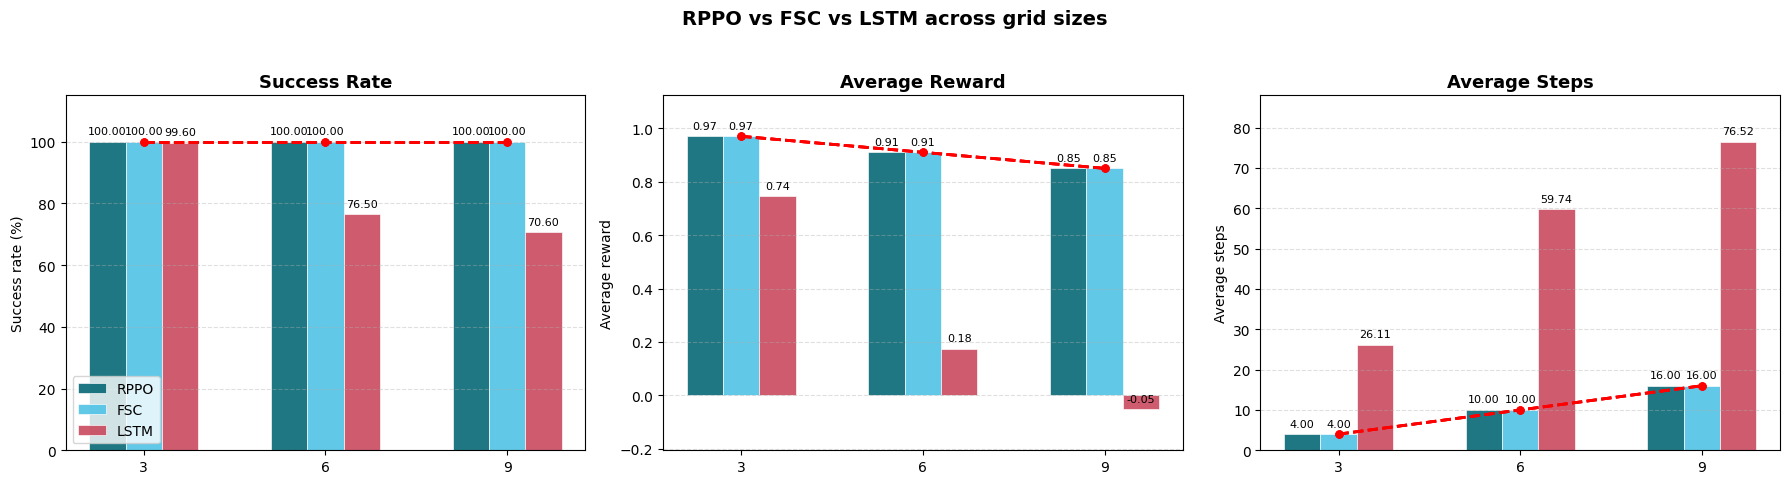

Saved comparison plot to: ./plots/Comparison/model_comparison_success_reward_steps.png


In [58]:
######################################################################
#                           Success Rate                             # 
######################################################################

number_of_episodes = 1000
results_fsc = {}
results_lstm = {}
results_rppo = {}

print("Evaluating Recurrent PPO models...")
for size, model in rppo_models_by_size.items():
    total_reward, total_steps, total_success = 0, 0, 0
    for i in range(number_of_episodes):
        reward, steps, success = run_rppo_episode(model, grid_size=size, max_steps=100)
        total_reward += reward
        total_steps += steps
        total_success += success

    results_rppo[size] = {
        "average_reward": total_reward / number_of_episodes,
        "average_steps": total_steps / number_of_episodes,
        "success_rate": total_success / number_of_episodes * 100
    }

print("Evaluating FSC models...")
for size, model in fsc_models_by_size.items():
    total_reward, total_steps, total_success = 0, 0, 0
    for i in range(number_of_episodes):
        reward, steps, success = run_fsc_episode(model, grid_size=size, max_steps=100, verbose=False)
        total_reward += reward
        total_steps += steps
        total_success += success

    results_fsc[size] = {
        "average_reward": total_reward / number_of_episodes,
        "average_steps": total_steps / number_of_episodes,
        "success_rate": total_success / number_of_episodes * 100
    }

print("Evaluating LSTM models...")
for size, model in lstm_models_by_size.items():
    total_reward, total_steps, total_success = 0, 0, 0
    for i in range(number_of_episodes):
        reward, steps, success = run_lstm_episode(model, grid_size=size, max_steps=100)
        total_reward += reward
        total_steps += steps
        total_success += success

    results_lstm[size] = {
        "average_reward": total_reward / number_of_episodes,
        "average_steps": total_steps / number_of_episodes,
        "success_rate": total_success / number_of_episodes * 100
    }

print("\n=== Success Rate Results ===\n")
plot_model_comparison_bars(results_rppo, results_fsc, results_lstm)

From the bar chart below, it can be observed that Recurrent PPO and the Finite State Controller (FSC) achieve nearly identical performance across all evaluated metrics. In particular, both models reach comparable values in terms of success rate, average number of steps, and cumulative reward. This suggests that the FSC has successfully learned to approximate the expert behavior, effectively reproducing the optimal navigation strategy required to solve the maze.

In contrast, the Behavioral Cloning LSTM exhibits significantly weaker performance. The model struggles to consistently complete episodes, and even in successful cases, the average cumulative reward remains low and often negative. This indicates that the policy frequently deviates from optimal trajectories and becomes disoriented within the environment, failing to maintain a reliable internal representation of its position in the maze.

Overall, these results highlight a clear performance gap between the FSC and the BC-LSTM, particularly in terms of reliability and task completion.

## Parameter Efficiency

The table below highlights one of the main advantages of the FSC: it requires far fewer parameters than the LSTM baseline. This does not automatically guarantee better accuracy in every setting, but it strongly improves model compactness and helps explain the lower inference cost. In the table below, an additional metric, Succ-Par, is reported, representing the success rate per trainable parameter. As introduced earlier in this chapter, this efficiency measure is computed for both the FSC and the LSTM models in order to highlight how effectively each architecture utilizes its parameter budget to achieve successful task completion.

| Maze Size | FSC | LSTM | FSC Succ-Par | LSTM Succ-Par |
|-----------|-----|------|--------------|---------------|
| 3x3 | 1,044 | 9,860 | 0,096 | 1,003e-2 |
| 6x6 | 1,044 | 71,428 | 0,096 | 1,103e-3 |
| 9x9 | 1,044 | 282,116 | 0,096 | 2,495e-4 |

## Computational Scalability

Training the FSC can still take several hours, especially on the 9x9 maze and for larger values of `M` such as 8 or 16. However, since the model already performs very well with `M = 4`, the practical training cost can be reduced substantially. In that setting, training time drops to a much more manageable range.

The LSTM baseline is faster to train, especially when using a GPU. In practice, training the three LSTM models is much quicker than sweeping several FSC configurations.

At inference time, however, the situation is reversed. The FSC is much cheaper per decision step, with response times around $10^{-7}$ seconds, while the LSTM is around $10^{-5}$ seconds. This gap is consistent with the large difference in parameter count.

In [59]:
def inference_time_fsc(fsc, grid_size, max_steps=100, n_episodes=100):
    '''
    Compute the average inference time per action for the given FSC model in the POMDPGridworld environment.

    Inputs:
    - fsc: An instance of the FSC model
    - grid_size: Size of the gridworld (e.g., 3, 6 or 9)
    - max_steps: Maximum number of steps to run in each episode (default: 100)
    - n_episodes: Number of episodes to average over (default: 100)

    Output:
    - Average inference time per action in seconds (float)
    '''
    
    env = POMDPGridworld(size=grid_size, max_steps=max_steps)
    obs, _ = env.reset()

    fsc.eval()
    with torch.no_grad():
        rho = F.softmax(fsc.theta_pi,  dim=0).numpy()  # (M,)
        pie = F.softmax(fsc.theta_pie, dim=0).numpy()  # (A, M)
        g   = F.softmax(fsc.theta_g,   dim=0).numpy()  # (M_next, M_prev, A, Y)

    belief = rho.copy()
    done = False
    truncated = False
    tot_time = 0.0

    while not (done or truncated):
        start = time.time()
        y_t = obs_to_index(obs)

        action_probs = pie @ belief            
        action = int(np.argmax(action_probs))
        tot_time += time.time() - start

        obs, _, done, truncated, _ = env.step(action)

        g_slice          = g[:, :, action, y_t]       
        new_belief_raw   = g_slice @ belief             
        z                = new_belief_raw.sum()
        new_belief       = new_belief_raw / z if z > 1e-12 else np.ones(fsc.M) / fsc.M

        belief = new_belief

    return tot_time

def inference_time_lstm(lstm, grid_size, max_steps=100, n_episodes=100):
    '''
    Compute the average inference time per action for the given LSTM model in the POMDPGridworld environment.

    Inputs:
    - lstm: An instance of the LSTM model
    - grid_size: Size of the gridworld (e.g., 3, 6 or 9)
    - max_steps: Maximum number of steps to run in each episode (default: 100)
    - n_episodes: Number of episodes to average over (default: 100)

    Output:
    - Average inference time per action in seconds (float)
    '''
    env = POMDPGridworld(size=grid_size, max_steps=max_steps)
    obs, _ = env.reset()

    lstm.eval()

    tot_time = 0.0
    done = False
    truncated = False

    while not (done or truncated):

        start = time.time()
        action = lstm.predict_action(obs)[0]
        tot_time += time.time() - start

        obs, _, done, truncated, _ = env.step(action)

    return tot_time

Size: 3x3 - FSC Inference Time: 9.298324584960938e-08 sec, LSTM Inference Time: 1.1301755905151367e-05 sec
Size: 6x6 - FSC Inference Time: 9.226799011230469e-08 sec, LSTM Inference Time: 3.555059432983399e-05 sec
Size: 9x9 - FSC Inference Time: 1.3828277587890624e-07 sec, LSTM Inference Time: 2.1184682846069337e-05 sec


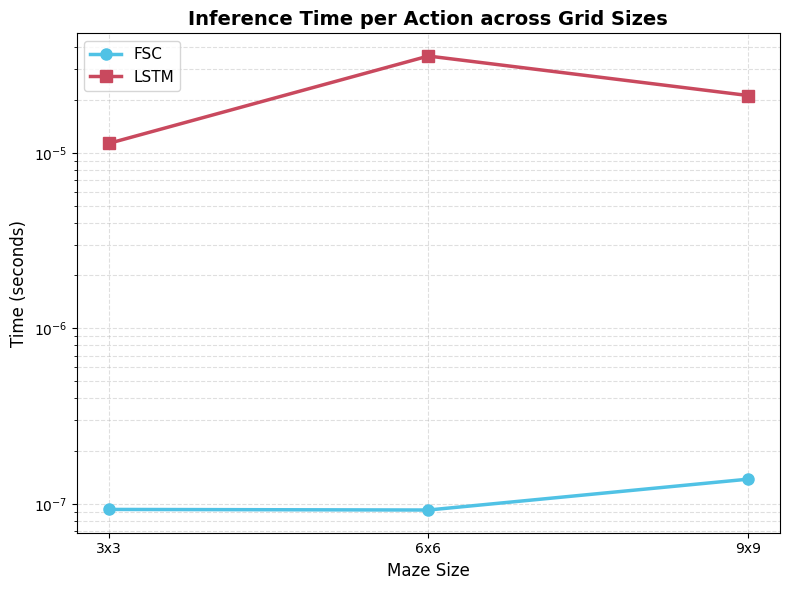

Saved inference time plot to: ./plots/Comparison/inference_time_comparison.png


In [100]:
######################################################################
#               Scale and Computational Complexity                   # 
######################################################################

inference_times_fsc = {}
inference_times_lstm = {}

number_of_episodes = 1000

for size, fsc in fsc_models_by_size.items():
    inference_time = inference_time_fsc(fsc, grid_size=size, max_steps=100, n_episodes=number_of_episodes)
    inference_times_fsc[size] = inference_time / number_of_episodes # Average time per episode

for size, lstm in lstm_models_by_size.items():
    inference_time = inference_time_lstm(lstm, grid_size=size, max_steps=100, n_episodes=number_of_episodes)
    inference_times_lstm[size] = inference_time / number_of_episodes # Average time per episode

for size in inference_times_fsc.keys():
    print(f"Size: {size}x{size} - FSC Inference Time: {inference_times_fsc[size]} sec, LSTM Inference Time: {inference_times_lstm[size]} sec")

plot_inference_time_comparison(inference_times_fsc, inference_times_lstm)

## Robustness to Distribution Shift

For the robustness analysis, I introduced action noise: with a given probability, the action executed by the environment differs from the action chosen by the agent.

Below I report the results for randomness levels of 0.1, 0.2, 0.3, 0.4 and 0.5. The FSC remains relatively stable even under fairly high noise levels. It can often recover and still complete the episode, although with a lower reward due to the additional steps.

The LSTM is much more sensitive to this perturbation. Once it is pushed off its nominal trajectory, it tends to accumulate too many extra steps and its reward quickly degrades.

In [60]:
def robustness_fsc(fsc, grid_size, randomness = 0.1, max_steps=100, n_episodes=100):
    '''
    Compute the average inference time per action for the given FSC model in the POMDPGridworld environment.

    Inputs:
    - fsc: An instance of the FSC model
    - grid_size: Size of the gridworld (e.g., 3, 6 or 9)
    - max_steps: Maximum number of steps to run in each episode (default: 100)
    - n_episodes: Number of episodes to average over (default: 100)

    Output:
    - Average inference time per action in seconds (float)
    '''
    
    env = POMDPGridworld(size=grid_size, max_steps=max_steps)
    obs, _ = env.reset()

    fsc.eval()
    with torch.no_grad():
        rho = F.softmax(fsc.theta_pi,  dim=0).numpy()  # (M,)
        pie = F.softmax(fsc.theta_pie, dim=0).numpy()  # (A, M)
        g   = F.softmax(fsc.theta_g,   dim=0).numpy()  # (M_next, M_prev, A, Y)

    belief = rho.copy()
    done = False
    truncated = False
    total_reward = 0.0
    step = 0

    while not (done or truncated):
        step += 1
        y_t = obs_to_index(obs)

        action_probs = pie @ belief            
        action = int(np.argmax(action_probs))

        if np.random.rand() < randomness:
            random_action = env.action_space.sample()
            while random_action == action:
                random_action = env.action_space.sample()
            action = random_action
        obs, reward, done, truncated, _ = env.step(action)
        total_reward += reward

        g_slice          = g[:, :, action, y_t]       
        new_belief_raw   = g_slice @ belief             
        z                = new_belief_raw.sum()
        new_belief       = new_belief_raw / z if z > 1e-12 else np.ones(fsc.M) / fsc.M

        belief = new_belief

    return total_reward, step, done

def robustness_lstm(lstm, grid_size, randomness = 0.1, max_steps=100, n_episodes=100):
    '''
    Compute the average inference time per action for the given LSTM model in the POMDPGridworld environment.

    Inputs:
    - lstm: An instance of the LSTM model
    - grid_size: Size of the gridworld (e.g., 3, 6 or 9)
    - max_steps: Maximum number of steps to run in each episode (default: 100)
    - n_episodes: Number of episodes to average over (default: 100)

    Output:
    - Average inference time per action in seconds (float)
    '''
    env = POMDPGridworld(size=grid_size, max_steps=max_steps)
    obs, _ = env.reset()

    lstm.eval()

    total_reward = 0.0
    step = 0
    done = False
    truncated = False

    while not (done or truncated):
        step += 1
        action = lstm.predict_action(obs)[0]

        if np.random.rand() < randomness:
            random_action = env.action_space.sample()
            while random_action == action:
                random_action = env.action_space.sample()
            action = random_action
        obs, reward, done, truncated, _ = env.step(action)
        total_reward += reward
        

    return total_reward, step, done

Evaluating FSC models with randomness 0.1...
Evaluating LSTM models with randomness 0.1...

=== Success Rate Results with randomness 0.1 ===



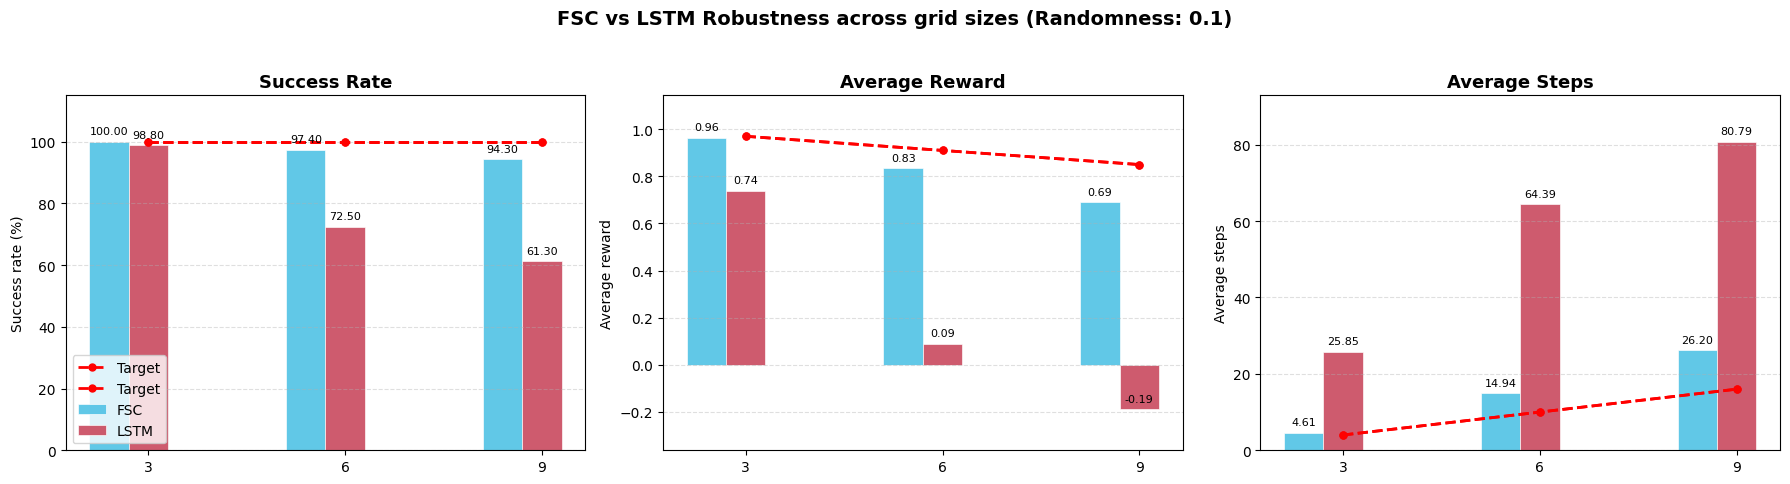

Saved comparison plot to: ./plots/Comparison/model_robustness_randomness_0.1.png
Evaluating FSC models with randomness 0.2...
Evaluating LSTM models with randomness 0.2...

=== Success Rate Results with randomness 0.2 ===



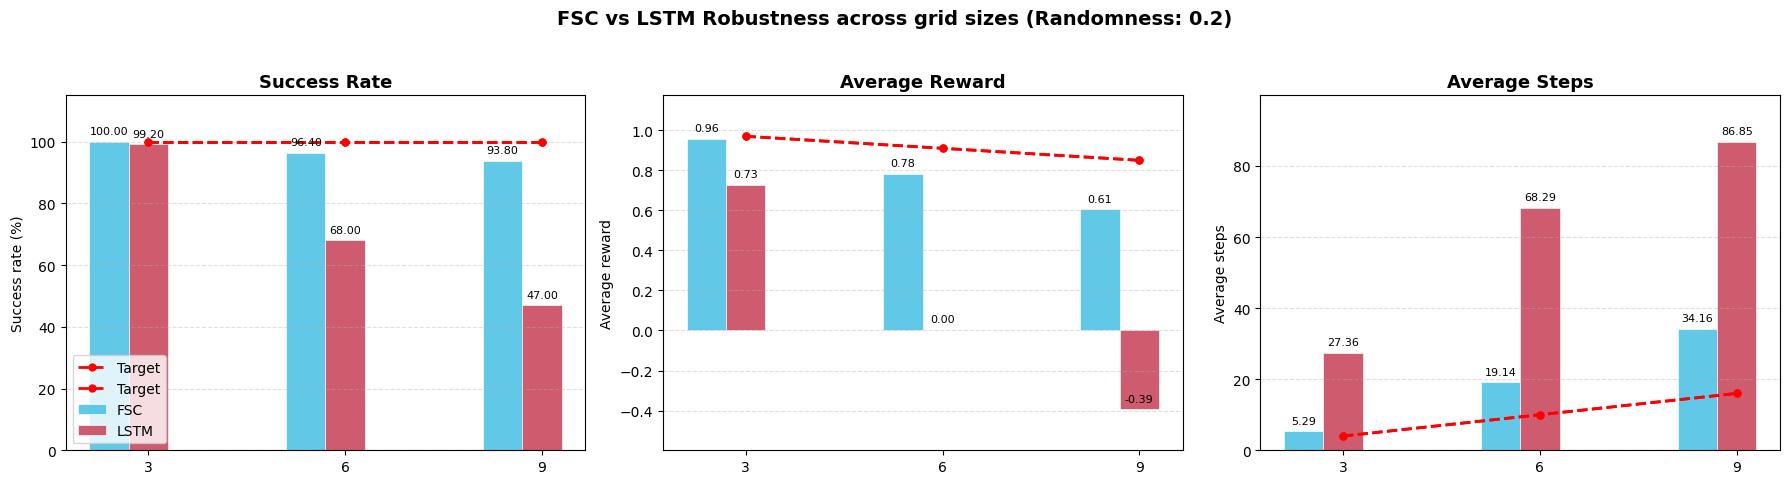

Saved comparison plot to: ./plots/Comparison/model_robustness_randomness_0.2.png
Evaluating FSC models with randomness 0.3...
Evaluating LSTM models with randomness 0.3...

=== Success Rate Results with randomness 0.3 ===



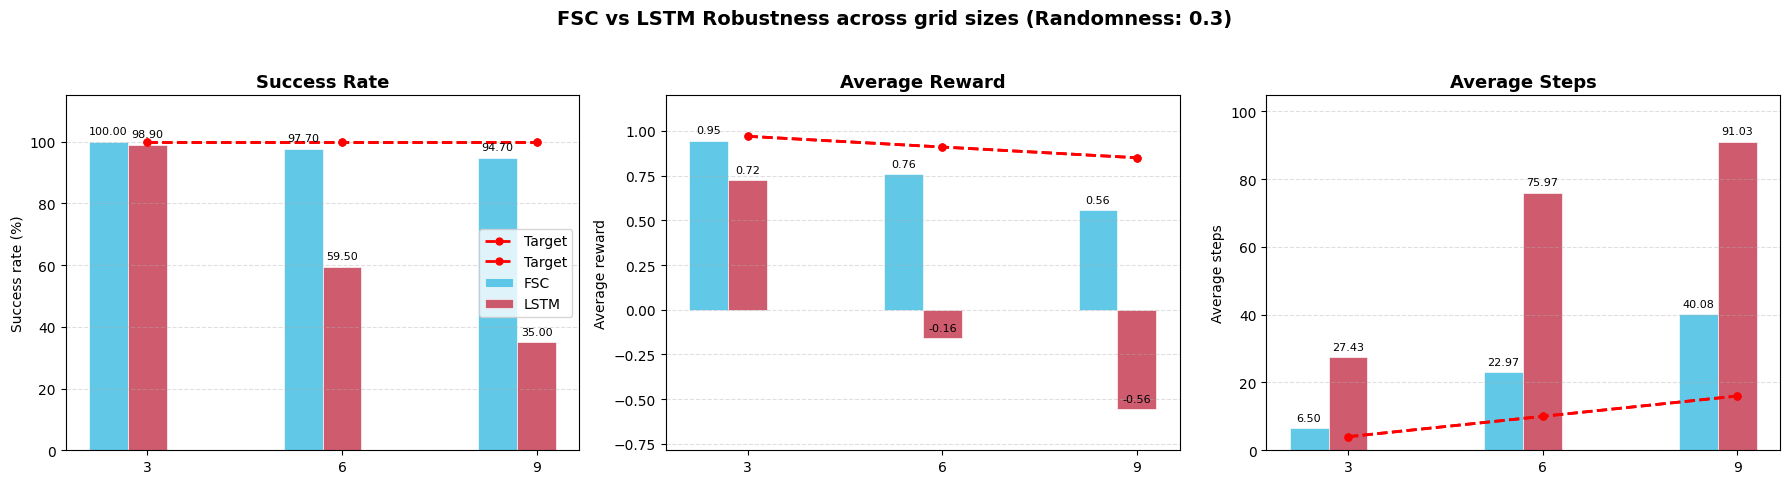

Saved comparison plot to: ./plots/Comparison/model_robustness_randomness_0.3.png
Evaluating FSC models with randomness 0.4...
Evaluating LSTM models with randomness 0.4...

=== Success Rate Results with randomness 0.4 ===



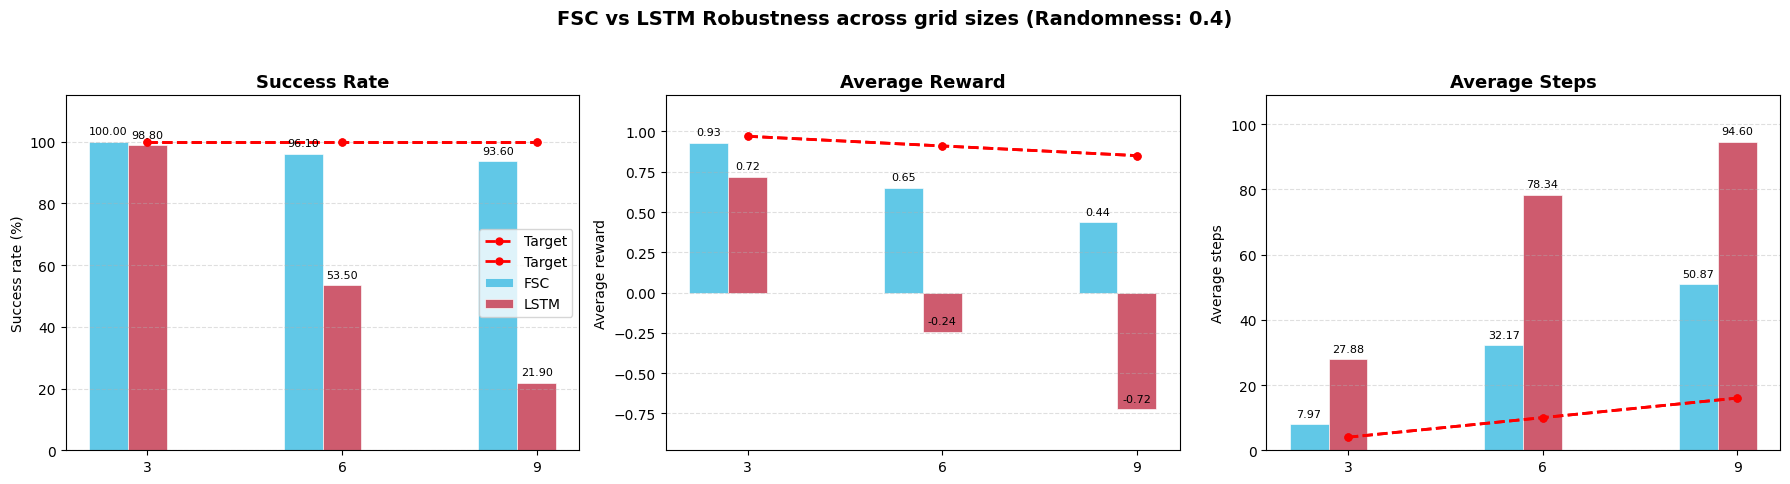

Saved comparison plot to: ./plots/Comparison/model_robustness_randomness_0.4.png
Evaluating FSC models with randomness 0.5...
Evaluating LSTM models with randomness 0.5...

=== Success Rate Results with randomness 0.5 ===



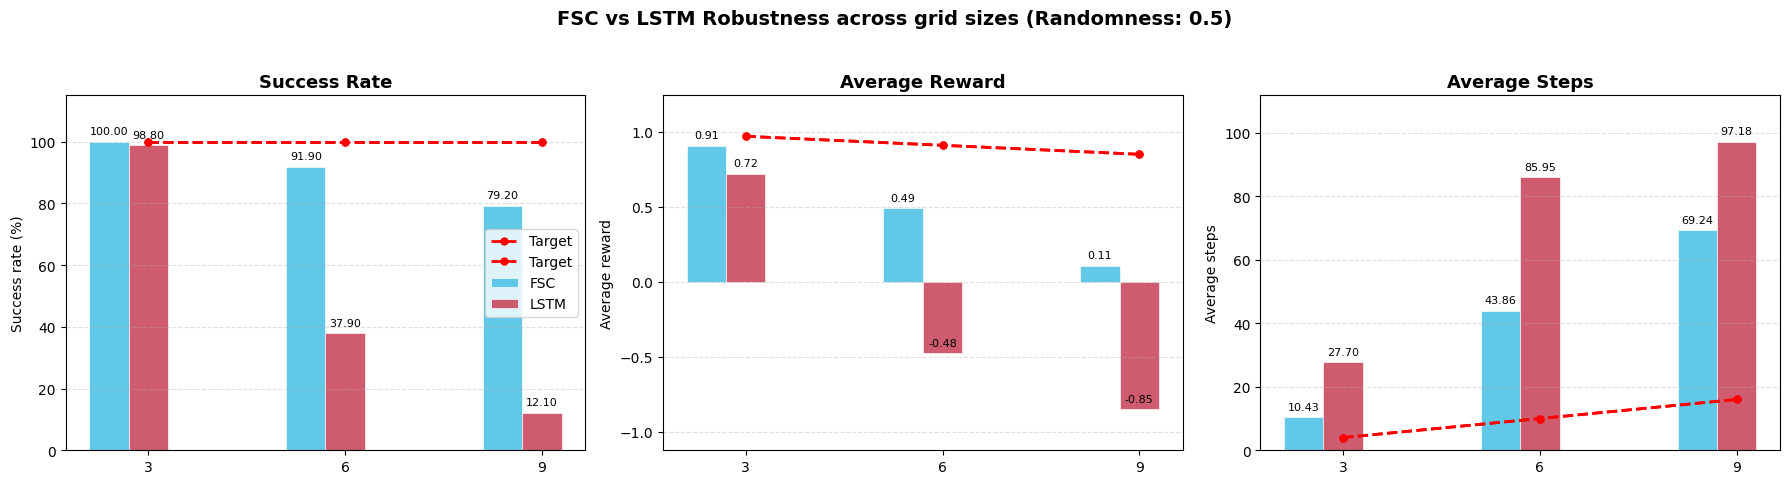

Saved comparison plot to: ./plots/Comparison/model_robustness_randomness_0.5.png


In [61]:
######################################################################
#                             Robustness                             # 
######################################################################

number_of_episodes = 1000
results_fsc = {}
results_lstm = {}
randomness = [0.1, 0.2, 0.3, 0.4, 0.5] # Different levels of randomness to test

for random in randomness:
    print(f"Evaluating FSC models with randomness {random}...")
    for size, model in fsc_models_by_size.items():
        total_reward, total_steps, total_success = 0, 0, 0
        for i in range(number_of_episodes):
            reward, steps, success = robustness_fsc(model, grid_size=size, randomness=random, n_episodes=number_of_episodes)
            total_reward += reward
            total_steps += steps
            total_success += success

        results_fsc[size] = {
            "average_reward": total_reward / number_of_episodes,
            "average_steps": total_steps / number_of_episodes,
            "success_rate": total_success / number_of_episodes * 100
        }
    
    print(f"Evaluating LSTM models with randomness {random}...")
    for size, model in lstm_models_by_size.items():
        total_reward, total_steps, total_success = 0, 0, 0
        for i in range(number_of_episodes):
            reward, steps, success = robustness_lstm(model, grid_size=size, randomness=random, n_episodes=number_of_episodes)
            total_reward += reward
            total_steps += steps
            total_success += success

        results_lstm[size] = {
            "average_reward": total_reward / number_of_episodes,
            "average_steps": total_steps / number_of_episodes,
            "success_rate": total_success / number_of_episodes * 100
        }
    
    print(f"\n=== Success Rate Results with randomness {random} ===\n")
    plot_robustness_bars(results_fsc, results_lstm, random, save_dir="./plots/Comparison")

In conclusion, the **FSC** demonstrates strong robustness and reliable recovery capabilities, maintaining stable performance even when repeatedly perturbed away from its optimal trajectory. In contrast, the **LSTM-based Behavioral Cloning model** is considerably more sensitive to small deviations: even under nominal conditions it already tends to drift away from the optimal path, and under perturbations these deviations accumulate, eventually leading to a complete failure in recovering a successful trajectory.

# Conclusion

This project suggests that, in this partially observable gridworld, FSCs provide a particularly strong balance between performance, compactness, robustness, and interpretability. When trained on trajectories generated by a recurrent RL expert, a small FSC is able to match the expert and outperform the LSTM imitation baseline on the larger mazes, while using far fewer parameters and substantially lower inference cost.

The LSTM remains a useful baseline because it is flexible, easy to optimize, and faster to train in practice, especially with GPU support. However, its behavior is harder to interpret, less parameter-efficient, and more sensitive when the task requires long-horizon memory or when execution noise perturbs the trajectory.

Overall, the results indicate that if the goal is not only to imitate behavior but also to recover a compact and understandable memory structure, FSCs are a very compelling solution. In contrast, if the priority is fast experimentation with a generic neural architecture, Behavioral Cloning with LSTMs remains a practical alternative, but it offers a weaker explanation of the learned policy.

It is also worth noting that this analysis does not fully do justice to the Behavioral Cloning approach. In particular, LSTM-based imitation learning typically requires significantly more careful hyperparameter tuning and may benefit substantially from larger and more diverse datasets. In such conditions, its performance could potentially become comparable to that of the FSC.

In this work, however, the comparison was intentionally designed to operate under a controlled and shared experimental setting, where both approaches are evaluated using the same amount of data and similar computational constraints. This choice was made in order to ensure a fair and balanced comparison between the two methods, rather than optimizing each model under its own ideal conditions.

Within this framework, the FSC appears to be more naturally suited to the task, demonstrating stronger performance, efficiency, and robustness. Nevertheless, it is important to emphasize that this advantage is not absolute: under different data regimes or with more extensive tuning, the Behavioral Cloning approach could plausibly achieve competitive results and potentially match the performance of the FSC.